
Objective:
- Perform WoE analysis on raw variables
- Identify monotonic trends
- Create coarse classing (grouping)
- Finalize binning rules
- Select final features for model

In [1]:
import sys
import os
sys.path.append("..")

import pandas as pd

from src.data_preprocessing import LoanDataPreprocessor
from src.data_split import split_data
from src.woe_binning import WoeBinner

In [2]:
pd.options.display.max_columns=None
pd.options.display.max_rows=100

In [3]:
data_processor=LoanDataPreprocessor()

INFO:root:Preprocessing version: v1.0


In [5]:
df=data_processor.preprocess('../data/loan_data_2007_2014.csv')

INFO:root:Cleaning employment length
INFO:root:Cleaning term
INFO:root:dates conversion
INFO:root:credit age creation
INFO:root:missing values handling
INFO:root:target variable creation
INFO:root:Applying outlier capping on 33 columns
INFO:root:final dataset shape: (466285, 81)


In [6]:
df.head(3)

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,emp_length_int,term_int,earliest_cr_line_date,credit_age_months,loan_status_clean,good_bad
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,0,10+ years,RENT,24000.0,Verified,2011-12-01,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,0.0,0.0,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.0,0.00,0.00,Jan-15,171.62,0,Jan-16,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5000.0,0.0,0.0,0.0,10.0,36,1985-01-01,327,Fully Paid,0
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,2011-12-01,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,0.0,0.0,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.0,117.08,1.11,Apr-13,119.66,0,Sep-13,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2500.0,0.0,0.0,0.0,0.0,60,1999-04-01,154,Charged Off,1
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,0,10+ years,RENT,12252.0,Not Verified,2011-12-01,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,0,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,0.0,0.0,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.0,0.00,0.00,Jun-14,649.91,0,Jan-16,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2400.0,0.0,0.0,0.0,10.0,36,2001-11-01,122,Fully Paid,0


In [7]:
df.shape

(466285, 81)

In [8]:
data_processor.validate_target(df)


===== TARGET VALIDATION =====

Configured BAD_STATUS values:
 - Charged Off
 - Default
 - Does not meet the credit policy. Status:Charged Off
 - Late (31-120 days)

Component Breakdown:
 loan_status
Charged Off                                            42475
Late (31-120 days)                                      6900
Default                                                  832
Does not meet the credit policy. Status:Charged Off      761
Name: count, dtype: int64

Total Bad Count: 50968
Sum of Components: 50968

✅ VALIDATION PASSED


In [9]:
df['loan_status'].unique()

array(['Fully Paid', 'Charged Off', 'Current', 'Default',
       'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [10]:
pd.options.display.max_rows=None

In [11]:
df.isnull().sum()

Unnamed: 0                     0
id                             0
member_id                      0
loan_amnt                      0
funded_amnt                    0
funded_amnt_inv                0
term                           0
int_rate                       0
installment                    0
grade                          0
sub_grade                      0
emp_title                      0
emp_length                     0
home_ownership                 0
annual_inc                     0
verification_status            0
issue_d                        0
loan_status                    0
pymnt_plan                     0
url                            0
desc                           0
purpose                        0
title                          0
zip_code                       0
addr_state                     0
dti                            0
delinq_2yrs                    0
earliest_cr_line               0
inq_last_6mths                 0
mths_since_last_delinq         0
mths_since

In [12]:
train_df,test_df=split_data(df)

In [13]:
print(train_df.shape, test_df.shape)


(373028, 81) (93257, 81)


In [14]:
train_df.columns

Index(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt',
       'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url',
       'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti',
       'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint',
       'verificatio

In [15]:
discrete_vars=[
    'grade',
    'home_ownership',
    'addr_state',
    'verification_status',
    'purpose',
    'initial_list_status',
]

In [16]:
woe_raw=WoeBinner()

X_train=train_df.drop(columns=['good_bad'])
y_train=train_df['good_bad']
woe_raw.fit(X_train,y_train,discrete_vars=discrete_vars)

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_woe_df(df, var_name):

    df=df.copy()
    if var_name in df.columns:
        X=df[var_name].astype(str)

    else:
        X=df.index.astype(str)
    
    
    y = df['WoE']
    
    plt.figure(figsize=(12,5))
    plt.plot(X, y, marker='o', linestyle='--')
    
    plt.xlabel(var_name)
    plt.ylabel('WoE')
    plt.title(f'WoE (Sorted) - {var_name}')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

In [18]:
def quick_eda(df, col,rotation_of_X_tick_lables=0):
    print(df[col].describe())
    print(f"\n--- Number of unique values ---")
    print(f'unique values:{df[col].nunique()}')
    print(f"\n---value counts ---")
    print(df[col].value_counts().head(10))
    print(f"\n---plot ---")
    plt.figure(figsize=(12,5))
    df[col].hist(bins=30)
    plt.xticks(rotation=rotation_of_X_tick_lables)
    plt.xlabel(col)
    plt.ylabel('count')
    

In [19]:
woe_raw.woe_tables

{'grade':   grade   n_obs  n_bad  n_good  prop_n_good  prop_n_bad       WoE        IV
 0     A   59859   2307   57552     0.173218    0.056592  1.118678  0.130467
 1     B  109416   8522  100894     0.303667    0.209018  0.373511  0.035352
 2     C  100475  11547   88928     0.267652    0.283207 -0.056491  0.000879
 3     D   61467   9531   51936     0.156316    0.233764 -0.402435  0.031168
 4     E   28524   5540   22984     0.069177    0.135883 -0.675120  0.045034
 5     F   10611   2579    8032     0.024176    0.063263 -0.961955  0.037600
 6     G    2676    748    1928     0.005804    0.018357 -1.151429  0.014454,
 'home_ownership':   home_ownership   n_obs  n_bad  n_good  prop_n_good  prop_n_bad       WoE  \
 0            ANY       1      0       1     0.000005    0.000012 -0.999243   
 1       MORTGAGE  188768  18098  170670     0.513675    0.443874  0.146051   
 2           NONE      42      6      36     0.000110    0.000159 -0.372345   
 3          OTHER     144     32     112

In [20]:
for var, table in woe_raw.woe_tables.items():
    print(f"\nVariable: {var}")
    print(table)


Variable: grade
  grade   n_obs  n_bad  n_good  prop_n_good  prop_n_bad       WoE        IV
0     A   59859   2307   57552     0.173218    0.056592  1.118678  0.130467
1     B  109416   8522  100894     0.303667    0.209018  0.373511  0.035352
2     C  100475  11547   88928     0.267652    0.283207 -0.056491  0.000879
3     D   61467   9531   51936     0.156316    0.233764 -0.402435  0.031168
4     E   28524   5540   22984     0.069177    0.135883 -0.675120  0.045034
5     F   10611   2579    8032     0.024176    0.063263 -0.961955  0.037600
6     G    2676    748    1928     0.005804    0.018357 -1.151429  0.014454

Variable: home_ownership
  home_ownership   n_obs  n_bad  n_good  prop_n_good  prop_n_bad       WoE  \
0            ANY       1      0       1     0.000005    0.000012 -0.999243   
1       MORTGAGE  188768  18098  170670     0.513675    0.443874  0.146051   
2           NONE      42      6      36     0.000110    0.000159 -0.372345   
3          OTHER     144     32     1

In [21]:
for var, table in woe_raw.woe_tables.items():
    print(f"\n--- {var} ---")
    print(table[['WoE', 'IV']])


--- grade ---
        WoE        IV
0  1.118678  0.130467
1  0.373511  0.035352
2 -0.056491  0.000879
3 -0.402435  0.031168
4 -0.675120  0.045034
5 -0.961955  0.037600
6 -1.151429  0.014454

--- home_ownership ---
        WoE        IV
0 -0.999243  0.000008
1  0.146051  0.010195
2 -0.372345  0.000018
3 -0.856142  0.000393
4  0.020963  0.000039
5 -0.165189  0.011762

--- addr_state ---
         WoE            IV
0   0.234118  1.295041e-04
1  -0.124386  2.024866e-04
2   0.004114  1.266572e-07
3  -0.042233  4.174055e-05
4  -0.048657  3.694229e-04
5   0.171348  5.729811e-04
6   0.196686  5.562378e-04
7   0.466161  5.601368e-04
8   0.013317  4.838561e-07
9  -0.164900  1.965241e-03
10  0.067321  1.421702e-04
11 -0.161039  1.483330e-04
12 -0.874080  3.123152e-05
13 -0.363254  4.070375e-06
14  0.159712  9.499827e-04
15  0.032636  1.467107e-05
16  0.237629  4.603880e-04
17  0.026395  6.588185e-06
18 -0.096995  1.151168e-04
19  0.038240  3.445593e-05
20 -0.050534  6.098214e-05
21  0.099369  1.2

count       373028
unique           6
top       MORTGAGE
freq        188768
Name: home_ownership, dtype: object

--- Number of unique values ---
unique values:6

---value counts ---
home_ownership
MORTGAGE    188768
RENT        150783
OWN          33290
OTHER          144
NONE            42
ANY              1
Name: count, dtype: int64

---plot ---


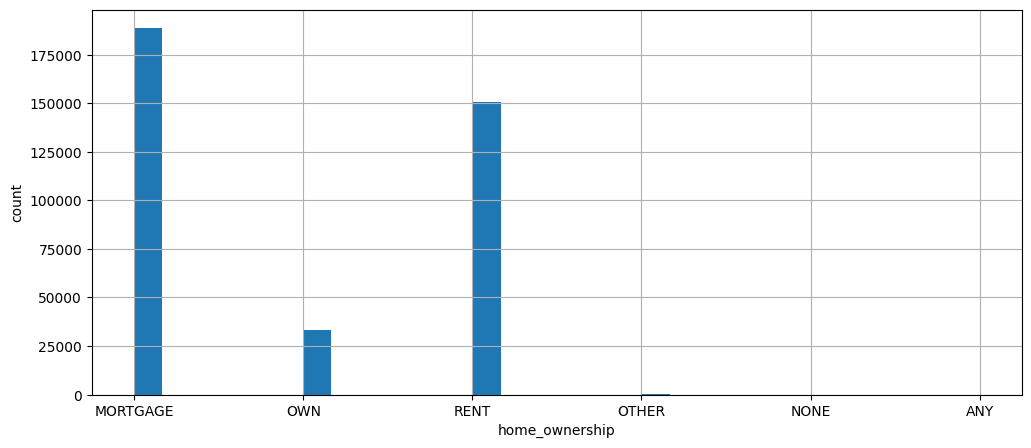

In [22]:
quick_eda(X_train, 'home_ownership')

  home_ownership   n_obs  n_bad  n_good  prop_n_good  prop_n_bad       WoE  \
0            ANY       1      0       1     0.000005    0.000012 -0.999243   
3          OTHER     144     32     112     0.000339    0.000797 -0.856142   
2           NONE      42      6      36     0.000110    0.000159 -0.372345   
5           RENT  150783  19067  131716     0.396433    0.467639 -0.165189   
4            OWN   33290   3571   29719     0.089448    0.087593  0.020963   
1       MORTGAGE  188768  18098  170670     0.513675    0.443874  0.146051   

         IV  
0  0.000008  
3  0.000393  
2  0.000018  
5  0.011762  
4  0.000039  
1  0.010195  


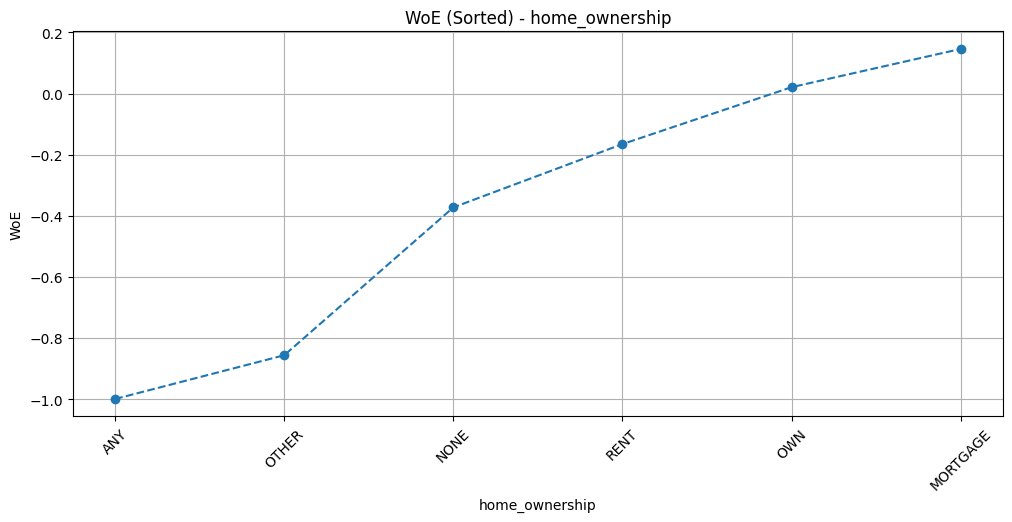

In [23]:
home_ownership_woe=woe_raw.woe_tables['home_ownership'].sort_values('WoE')
iv_raw=woe_raw.iv_summary()
print(home_ownership_woe)
plot_woe_df(home_ownership_woe, 'home_ownership')


In [24]:
train_df['home_ownership_grp']=train_df['home_ownership'].replace({
    'RENT': 'RENT',
    'OWN': 'OWN',
    'MORTGAGE': 'MORTGAGE',
    'ANY': 'OTHER',
    'NONE': 'OTHER',
    'OTHER': 'OTHER'})
    

In [25]:
woe_grp=WoeBinner()

                     n_obs  n_bad  n_good  prop_n_good  prop_n_bad       WoE  \
home_ownership_grp                                                             
MORTGAGE            188768  18098  170670     0.513675    0.443874  0.146051   
OWN                  33290   3571   29719     0.089448    0.087593  0.020963   
RENT                150783  19067  131716     0.396433    0.467639 -0.165189   
OTHER                  187     38     149     0.000450    0.000944 -0.741217   

                          IV  
home_ownership_grp            
MORTGAGE            0.010195  
OWN                 0.000039  
RENT                0.011762  
OTHER               0.000366  


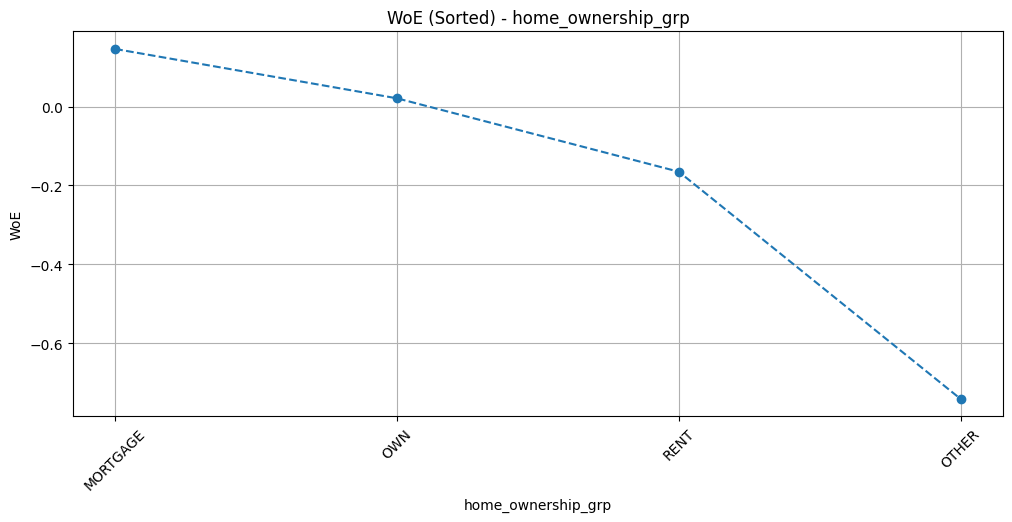

In [26]:
woe_grp.fit(train_df.drop(columns=['good_bad']),
        y_train,
        discrete_vars=['home_ownership_grp'])


woe_table=woe_grp.woe_tables['home_ownership_grp']
iv_grp=woe_grp.iv_summary()
woe_table=woe_table.set_index('home_ownership_grp')
order=['MORTGAGE','OWN','RENT','OTHER']
woe_table=woe_table.loc[order]

print(woe_table)
plot_woe_df(woe_table, 'home_ownership_grp')

In [27]:
print('IV Raw:', iv_raw)
print('IV grouped:', iv_grp)

IV Raw:               Variable        IV
0                grade  0.294955
4              purpose  0.038088
5  initial_list_status  0.023626
1       home_ownership  0.022414
3  verification_status  0.021374
2           addr_state  0.012811
IV grouped:              Variable        IV
0  home_ownership_grp  0.022362


**Home Ownership**  
- WoE analysis showed a clear monotonic risk pattern across home ownership categories:  
    -  **MORTGAGE** → lowest risk  
     - **OWN** → relatively safer segment 
     - **RENT** → moderately higher risk  
     - **OTHER** → highest risk segment  
- Sparse categories (ANY, NONE, OTHER) were consolidated into a single OTHER bucket due to low observation counts and unstable standalone WoE estimates.    
- Separate grouping for RENT and OWN was retained to preserve distinct borrower risk behavior and improve interpretability.  
- Grouped variable achieved a stable monotonic WoE trend with improved statistical robustness and reduced overfitting risk.  
- IV change was negligible:  
   - **Raw IV**: 0.022414  
   - **Grouped IV**: 0.022362  
- Minimal information loss indicates grouping preserved predictive power while improving stability and business interpretability.  
- Final variable used:  
 - home_ownership_grp

count     373028
unique         7
top            B
freq      109416
Name: grade, dtype: object

--- Number of unique values ---
unique values:7

---value counts ---
grade
B    109416
C    100475
D     61467
A     59859
E     28524
F     10611
G      2676
Name: count, dtype: int64

---plot ---


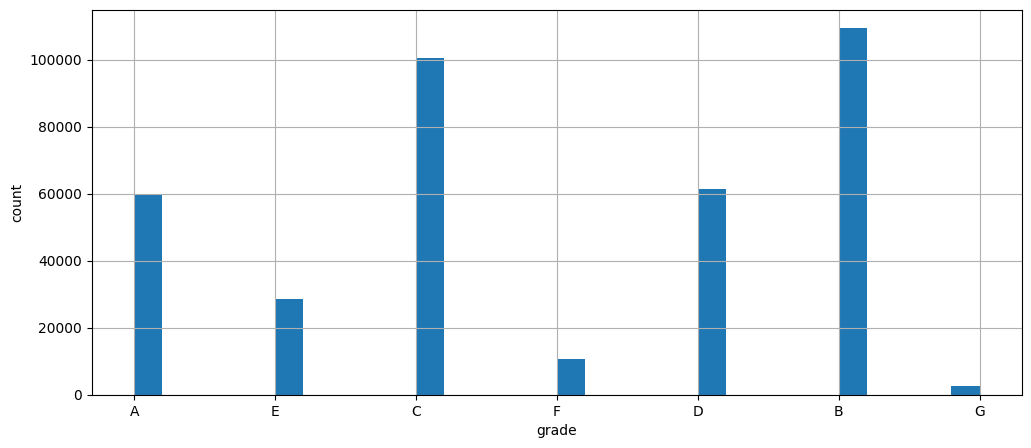

In [28]:
quick_eda(X_train, 'grade')

  grade   n_obs  n_bad  n_good  prop_n_good  prop_n_bad       WoE        IV
0     A   59859   2307   57552     0.173218    0.056592  1.118678  0.130467
1     B  109416   8522  100894     0.303667    0.209018  0.373511  0.035352
2     C  100475  11547   88928     0.267652    0.283207 -0.056491  0.000879
3     D   61467   9531   51936     0.156316    0.233764 -0.402435  0.031168
4     E   28524   5540   22984     0.069177    0.135883 -0.675120  0.045034
5     F   10611   2579    8032     0.024176    0.063263 -0.961955  0.037600
6     G    2676    748    1928     0.005804    0.018357 -1.151429  0.014454


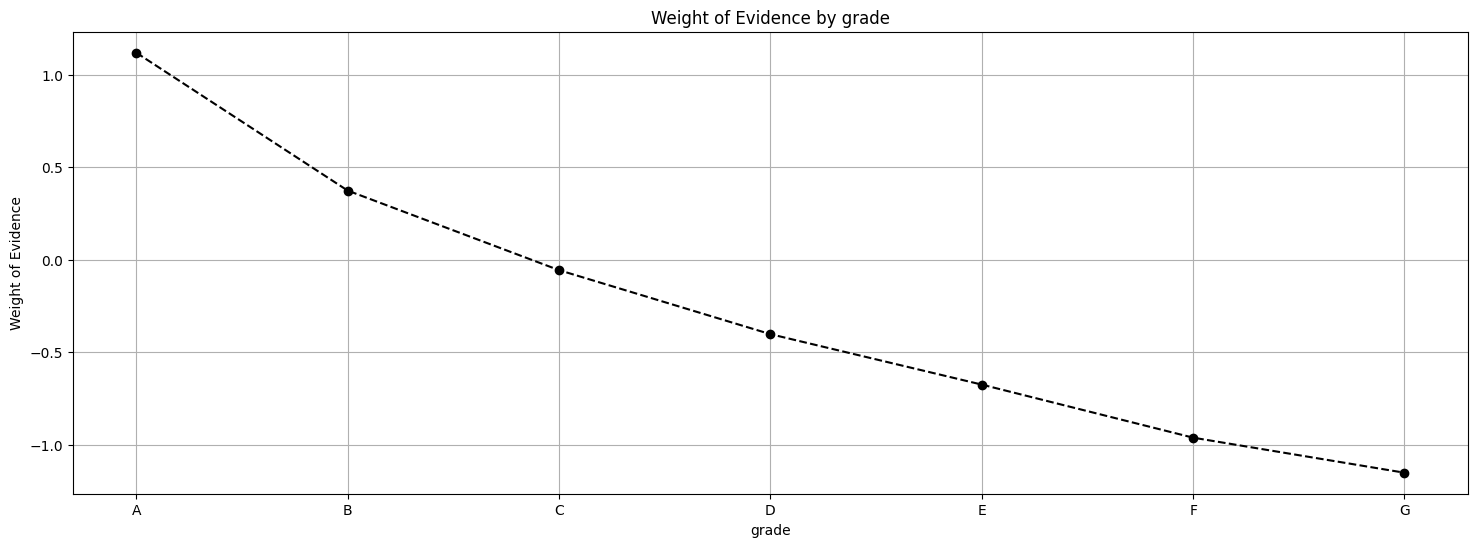

              Variable        IV
0                grade  0.294955
4              purpose  0.038088
5  initial_list_status  0.023626
1       home_ownership  0.022414
3  verification_status  0.021374
2           addr_state  0.012811


In [29]:
print(woe_raw.woe_tables['grade'])
woe_raw.plot_woe('grade')
print(iv_raw)

**grade**

- WoE shows a clear monotonic decreasing trend from A to G, indicating increasing credit risk
- Variable is inherently ordinal with meaningful business interpretation
- All categories have sufficient observations, ensuring stable WoE estimates
- High predictive power observed (IV ≈ 0.29)
- No grouping required; variable retained as is

count     373028
unique        50
top           CA
freq       57112
Name: addr_state, dtype: object

--- Number of unique values ---
unique values:50

---value counts ---
addr_state
CA    57112
NY    32173
TX    29153
FL    25283
IL    14788
NJ    14490
PA    13193
OH    12218
GA    12013
VA    11370
Name: count, dtype: int64

---plot ---


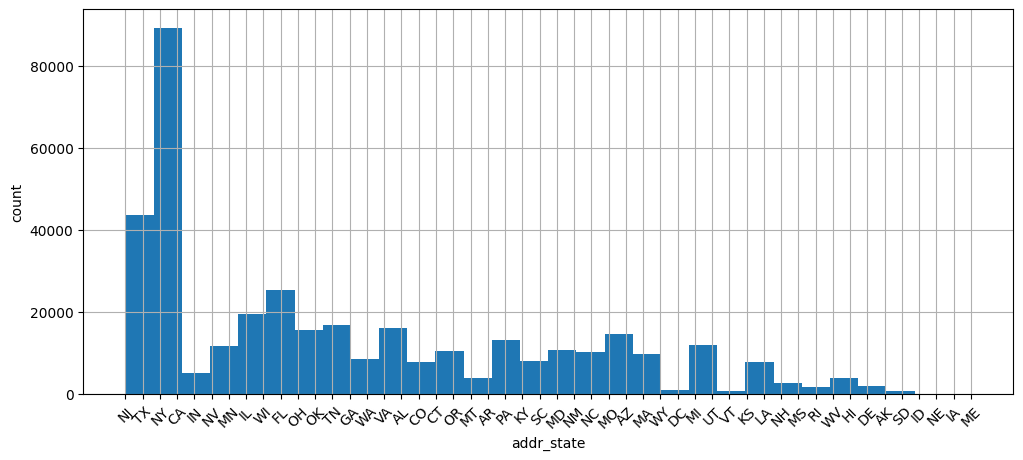

In [30]:
quick_eda(X_train, 'addr_state',45)

In [31]:
pd.set_option('display.float_format', '{:.8f}'.format)

   addr_state  n_obs  n_bad  n_good  prop_n_good  prop_n_bad         WoE  \
28         NE     11      7       4   0.00001354  0.00018394 -2.60868074   
12         IA     10      2       8   0.00002558  0.00006131 -0.87407968   
13         ID      9      1       8   0.00002558  0.00003679 -0.36325406   
32         NV   5168    715    4453   0.01340390  0.01754795 -0.26939113   
9          FL  25283   3196   22087   0.06647775  0.07839555 -0.16489974   
11         HI   2003    252    1751   0.00527157  0.00619267 -0.16103852   
1          AL   4650    567    4083   0.01229030  0.01391818 -0.12438612   
18         LA   4394    523    3871   0.01165223  0.01283906 -0.09699484   
35         OK   3310    387    2923   0.00879899  0.00950361 -0.07703415   
33         NY  32173   3738   28435   0.08558362  0.09168833 -0.06890121   
31         NM   2078    240    1838   0.00553342  0.00589837 -0.06386990   
27         NC  10171   1171    9000   0.02708921  0.02873154 -0.05885996   
20         M

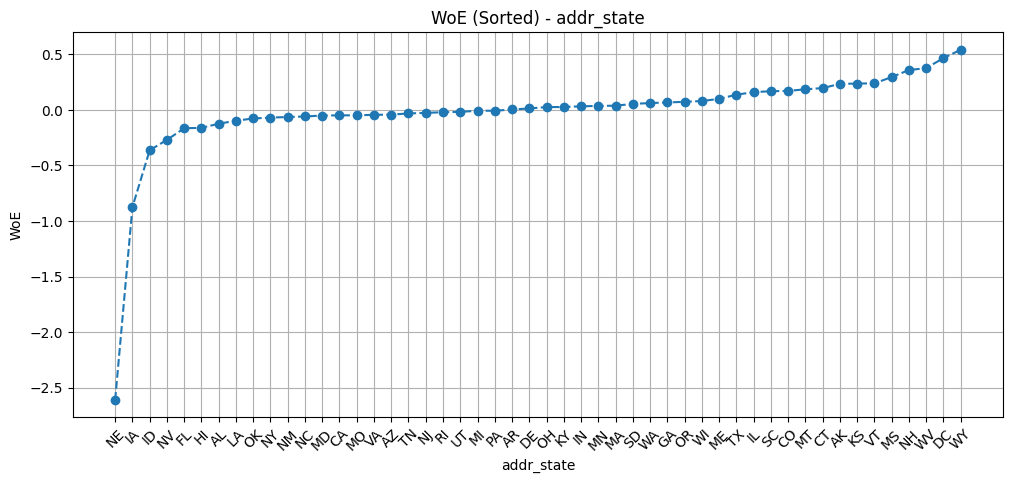

              Variable         IV
0                grade 0.29495460
4              purpose 0.03808774
5  initial_list_status 0.02362604
1       home_ownership 0.02241447
3  verification_status 0.02137440
2           addr_state 0.01281067


In [32]:
addr_woe=woe_raw.woe_tables['addr_state'].sort_values('WoE')
print(addr_woe)
plot_woe_df(addr_woe, 'addr_state')
print(iv_raw)

In [33]:
def group_state(row):
    woe=row['WoE']

    
    if row['n_bad']==0:
        return 'OTHER'
    if row['n_obs']<1000:
        return 'OTHER'

    if woe<-0.05:
        return 'HIGH_RISK'
    elif woe<0.1:
        return 'MEDIUM_RISK'
    else:
        return 'LOW_RISK'   
    
    

In [34]:
addr_woe['addr_state_grp']=addr_woe.apply(group_state,axis=1)

In [35]:
addr_woe.head()

,addr_state,n_obs,n_bad,n_good,prop_n_good,prop_n_bad,WoE,IV,addr_state_grp
28,NE,11,7,4,0.00001354,0.00018394,-2.60868074,0.00044451,OTHER
12,IA,10,2,8,0.00002558,0.00006131,-0.87407968,0.00003123,OTHER
13,ID,9,1,8,0.00002558,0.00003679,-0.36325406,0.00000407,OTHER
32,NV,5168,715,4453,0.01340390,0.01754795,-0.26939113,0.00111637,HIGH_RISK
9,FL,25283,3196,22087,0.06647775,0.07839555,-0.16489974,0.00196524,HIGH_RISK


In [36]:
#addr_woe.sort_values('WoE')

In [37]:
addr_state_grp_dict=dict(
    zip(addr_woe['addr_state'], addr_woe['addr_state_grp']))

In [38]:
addr_state_grp_dict

{'NE': 'OTHER',
 'IA': 'OTHER',
 'ID': 'OTHER',
 'NV': 'HIGH_RISK',
 'FL': 'HIGH_RISK',
 'HI': 'HIGH_RISK',
 'AL': 'HIGH_RISK',
 'LA': 'HIGH_RISK',
 'OK': 'HIGH_RISK',
 'NY': 'HIGH_RISK',
 'NM': 'HIGH_RISK',
 'NC': 'HIGH_RISK',
 'MD': 'HIGH_RISK',
 'CA': 'MEDIUM_RISK',
 'MO': 'MEDIUM_RISK',
 'VA': 'MEDIUM_RISK',
 'AZ': 'MEDIUM_RISK',
 'TN': 'MEDIUM_RISK',
 'NJ': 'MEDIUM_RISK',
 'RI': 'MEDIUM_RISK',
 'UT': 'MEDIUM_RISK',
 'MI': 'MEDIUM_RISK',
 'PA': 'MEDIUM_RISK',
 'AR': 'MEDIUM_RISK',
 'DE': 'MEDIUM_RISK',
 'OH': 'MEDIUM_RISK',
 'KY': 'MEDIUM_RISK',
 'IN': 'MEDIUM_RISK',
 'MN': 'MEDIUM_RISK',
 'MA': 'MEDIUM_RISK',
 'SD': 'OTHER',
 'WA': 'MEDIUM_RISK',
 'GA': 'MEDIUM_RISK',
 'OR': 'MEDIUM_RISK',
 'WI': 'MEDIUM_RISK',
 'ME': 'OTHER',
 'TX': 'LOW_RISK',
 'IL': 'LOW_RISK',
 'SC': 'LOW_RISK',
 'CO': 'LOW_RISK',
 'MT': 'LOW_RISK',
 'CT': 'LOW_RISK',
 'AK': 'OTHER',
 'KS': 'LOW_RISK',
 'VT': 'OTHER',
 'MS': 'OTHER',
 'NH': 'LOW_RISK',
 'WV': 'LOW_RISK',
 'DC': 'LOW_RISK',
 'WY': 'OTHER'}

In [39]:
train_df['addr_state_grp']=train_df['addr_state'].map(addr_state_grp_dict).fillna('OTHER')

  addr_state_grp   n_obs  n_bad  n_good  prop_n_good  prop_n_bad         WoE  \
0      HIGH_RISK   97963  11787   86176   0.25936934  0.28909354 -0.10849724   
2    MEDIUM_RISK  199387  21944  177443   0.53405979  0.53819836 -0.00771940   
1       LOW_RISK   71311   6664   64647   0.19457253  0.16344975  0.17429939   
3          OTHER    4367    379    3988   0.01200437  0.00930740  0.25446079   

          IV  
0 0.00322499  
2 0.00003195  
1 0.00542468  
3 0.00068627  


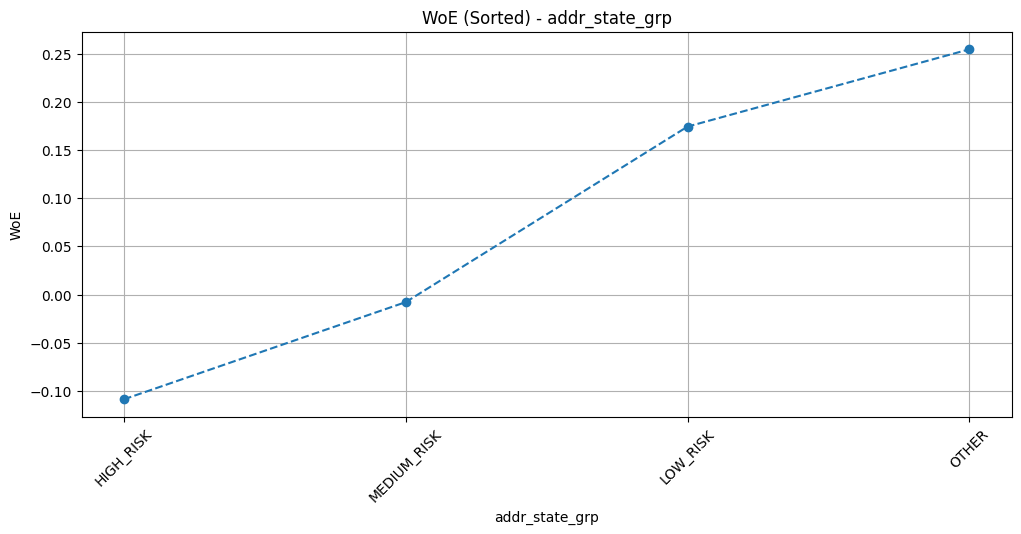

In [40]:
woe_grp.fit(train_df.drop(columns=['good_bad']),
        y_train, discrete_vars=['addr_state_grp'])

woe_table=woe_grp.woe_tables['addr_state_grp']
iv_grp=woe_grp.iv_summary()
woe_table=woe_table.sort_values('WoE')

print(woe_table)
plot_woe_df(woe_table, 'addr_state_grp')

In [41]:
print('IV Raw:', iv_raw)
print('IV grouped:', iv_grp)

IV Raw:               Variable         IV
0                grade 0.29495460
4              purpose 0.03808774
5  initial_list_status 0.02362604
1       home_ownership 0.02241447
3  verification_status 0.02137440
2           addr_state 0.01281067
IV grouped:          Variable         IV
0  addr_state_grp 0.00936790


#### addr_state
- The variable has high cardinality (~50 states) with uneven population distribution and several sparse categories.  
- Initial WoE analysis showed significant variation across states, with some extreme WoE values driven by low observation counts and unstable default distributions.  
- To improve stability and reduce noise, grouping was performed using stability-driven criteria:    
    - States with very low observations were grouped into an OTHER category  
    - States were grouped based on WoE similarity into broader risk segments  
- Remaining states were grouped into:  
    - **HIGH_RISK** → materially negative WoE indicating higher default tendency  
    - **MEDIUM_RISK** → near-neutral WoE indicating average risk behavior  
    - **LOW_RISK** → positive WoE indicating relatively lower default risk  
- The OTHER category represents statistically unstable or sparse state segments rather than a specific business risk level and acts as a stabilizing bucket.  
- Grouping significantly reduced dimensionality while improving:  
    - statistical robustness  
    -  interpretability  
    - model stability  
    - resistance to overfitting  
- Post-grouping WoE exhibited a smoother and more stable monotonic trend across risk buckets, supporting consistent borrower risk ranking.  
- IV decreased moderately due to reduced granularity:
  - **Raw IV**: 0.012811  
  - **Grouped IV**: ~0.009 (post-grouping value)  
- The reduction in granularity is acceptable as grouping improves stability and reduces sensitivity to noisy state-level fluctuations.  
- Final variable used:
    - addr_state_grp

count                 373028
unique                    14
top       debt_consolidation
freq                  219513
Name: purpose, dtype: object

--- Number of unique values ---
unique values:14

---value counts ---
purpose
debt_consolidation    219513
credit_card            83208
home_improvement       21206
other                  18988
major_purchase          7856
small_business          5577
car                     4244
medical                 3724
moving                  2423
vacation                1983
Name: count, dtype: int64

---plot ---


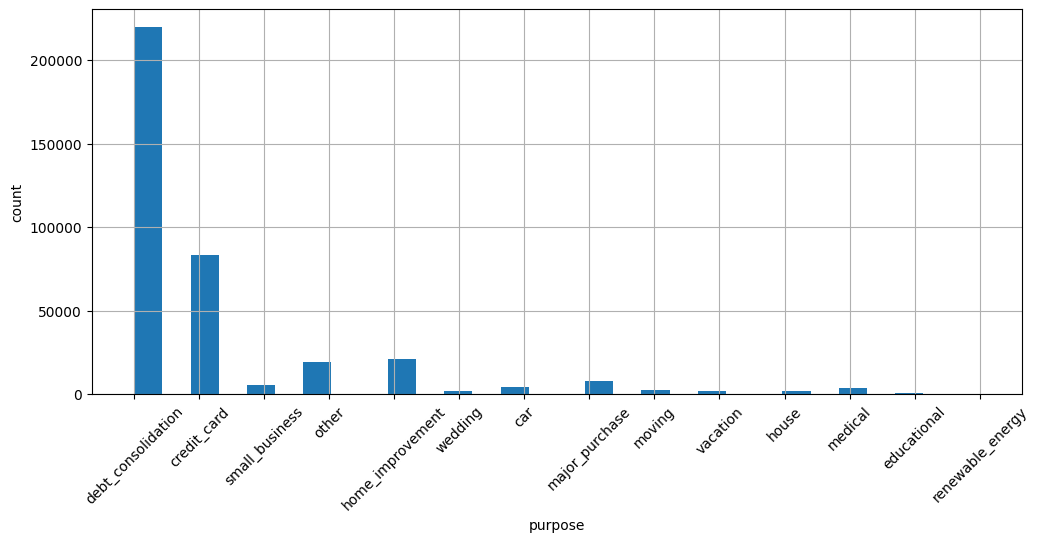

In [42]:
quick_eda(X_train, 'purpose',45)

               purpose   n_obs  n_bad  n_good  prop_n_good  prop_n_bad  \
11      small_business    5577   1193    4384   0.01319623  0.02927110   
3          educational     357     70     287   0.00086530  0.00172904   
8               moving    2423    379    2044   0.00615342  0.00930740   
10    renewable_energy     279     42     237   0.00071481  0.00104233   
5                house    1813    260    1553   0.00467564  0.00638888   
7              medical    3724    515    3209   0.00965978  0.01264286   
9                other   18988   2618   16370   0.04927104  0.06421985   
12            vacation    1983    240    1743   0.00524749  0.00589837   
13             wedding    1857    215    1642   0.00494351  0.00528523   
2   debt_consolidation  219513  24930  194583   0.58564682  0.61143130   
4     home_improvement   21206   2069   19137   0.05759901  0.05075538   
6       major_purchase    7856    757    7099   0.02136769  0.01857802   
0                  car    4244    386 

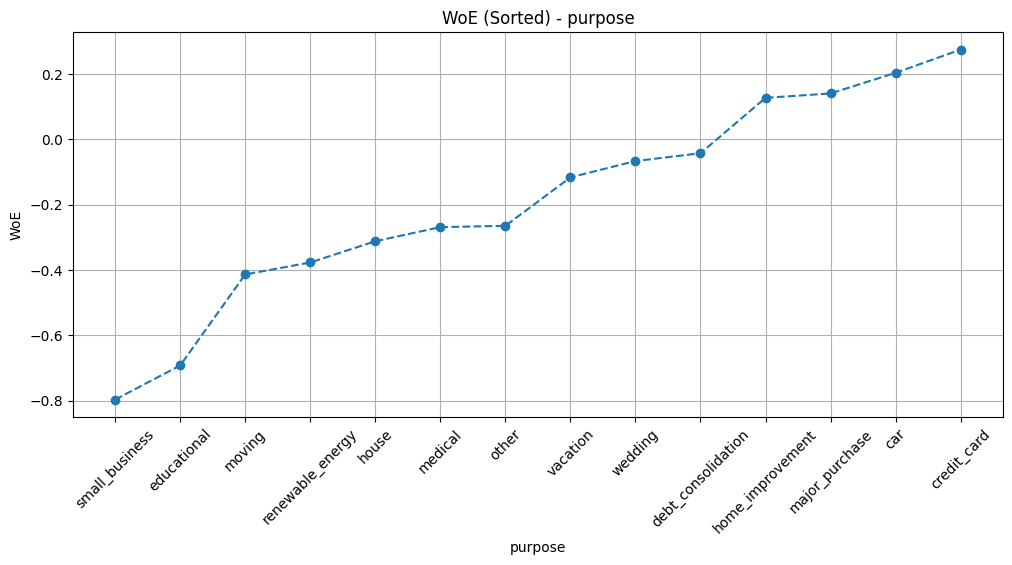

In [43]:
purpose_woe=woe_raw.woe_tables['purpose'].sort_values('WoE')
print(purpose_woe)
plot_woe_df(purpose_woe, 'purpose')

In [44]:
purpose_grp = {

    # HIGH RISK
    'small_business': 'high_risk',
    'educational': 'high_risk',
    'moving': 'high_risk',
    'renewable_energy': 'high_risk',
    'house': 'high_risk',
    'medical': 'high_risk',
    'other': 'high_risk',

    # MEDIUM RISK
    'vacation': 'medium_risk',
    'wedding': 'medium_risk',
    'debt_consolidation': 'medium_risk',

    # LOW RISK
    'home_improvement': 'low_risk',
    'major_purchase': 'low_risk',
    'car': 'low_risk',
    'credit_card': 'low_risk'
}

In [45]:
train_df['purpose_grp'] = train_df['purpose'].map(purpose_grp).fillna('missing_purpose')

   purpose_grp   n_obs  n_bad  n_good  prop_n_good  prop_n_bad         WoE  \
0    high_risk   33161   5077   28084   0.08452720  0.12452789 -0.38745631   
2  medium_risk  223353  25385  197968   0.59583481  0.62259038 -0.04392533   
1     low_risk  116514  10312  106202   0.31964250  0.25291853  0.23413578   

          IV  
0 0.01549852  
2 0.00117525  
1 0.01562247  


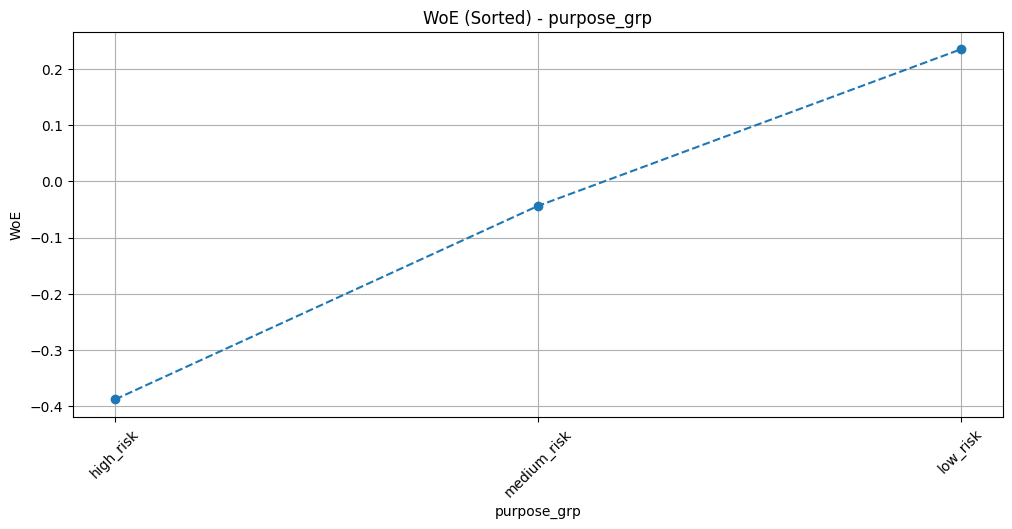

In [46]:
woe_grp.fit(train_df.drop(columns=['good_bad']),
        y_train, discrete_vars=['purpose_grp'])

woe_table=woe_grp.woe_tables['purpose_grp']
iv_grp=woe_grp.iv_summary()
woe_table=woe_table.sort_values('WoE')

print(woe_table)
plot_woe_df(woe_table, 'purpose_grp')

In [47]:
print('IV Raw:', iv_raw)
print('IV grouped:', iv_grp)

IV Raw:               Variable         IV
0                grade 0.29495460
4              purpose 0.03808774
5  initial_list_status 0.02362604
1       home_ownership 0.02241447
3  verification_status 0.02137440
2           addr_state 0.01281067
IV grouped:       Variable         IV
0  purpose_grp 0.03229624


#### purpose
- The variable contains multiple borrower purpose categories with varying default behavior and uneven observation distributions across segments.  
- Initial WoE analysis showed a meaningful separation in borrower risk profiles:  
    - Strongly negative WoE → higher default tendency
    -  Near-zero WoE → average/default-neutral behavior
    - Positive WoE → relatively lower default tendency
- Categories exhibiting materially negative WoE values were grouped into a HIGH_RISK segment:
    - small_business
    - educational
    - moving
    - renewable_energy
    - house
    - medical
    - other
- Categories with near-neutral WoE behavior were grouped into a MEDIUM_RISK segment:
    - vacation
    - wedding
    - debt_consolidation
- Categories with consistently positive WoE values were grouped into a LOW_RISK segment:
    - home_improvement
    - major_purchase
    - car
    - credit_card
- Grouping was performed to:
    - improve statistical stability
    - reduce noise from low-frequency categories
    - improve interpretability
    - reduce overfitting risk
    - achieve smoother monotonic WoE behavior
- Post-grouping WoE exhibited a clear and meaningful monotonic relationship:
    - HIGH_RISK → negative WoE
    - MEDIUM_RISK → near-neutral WoE
    - LOW_RISK → positive WoE
- The grouped structure produced a more stable and business-interpretable risk segmentation compared to the raw category-level distribution.
- IV decreased only marginally after grouping:
    - Raw IV: 0.038088
    - Grouped IV: 0.032296
- Minimal information loss indicates grouping preserved predictive power while improving robustness and model consistency.
- Final variable used:
    - purpose_grp

count     373028
unique         2
top            f
freq      242387
Name: initial_list_status, dtype: object

--- Number of unique values ---
unique values:2

---value counts ---
initial_list_status
f    242387
w    130641
Name: count, dtype: int64

---plot ---


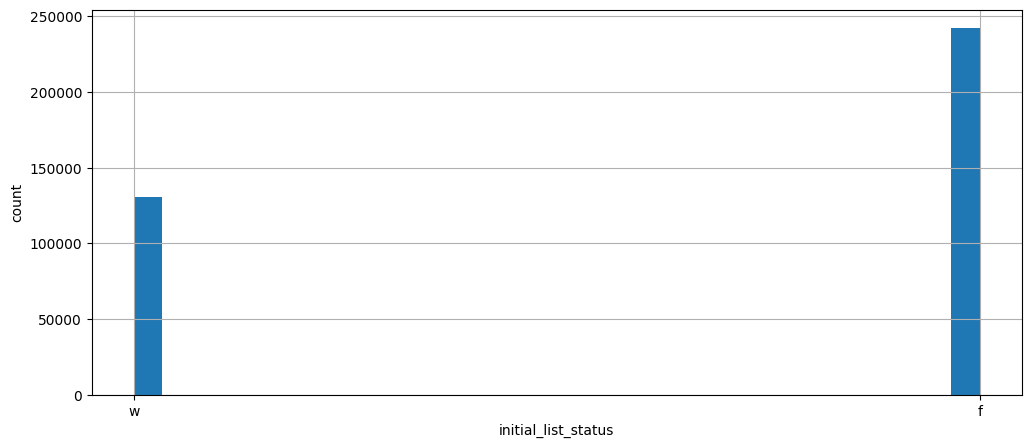

In [48]:
quick_eda(X_train, 'initial_list_status')

  initial_list_status   n_obs  n_bad  n_good  prop_n_good  prop_n_bad  \
0                   f  242387  29099  213288   0.64194412  0.71367783   
1                   w  130641  11675  118966   0.35805889  0.28634669   

          WoE         IV  
0 -0.10593040 0.00759878  
1  0.22349420 0.01602726  


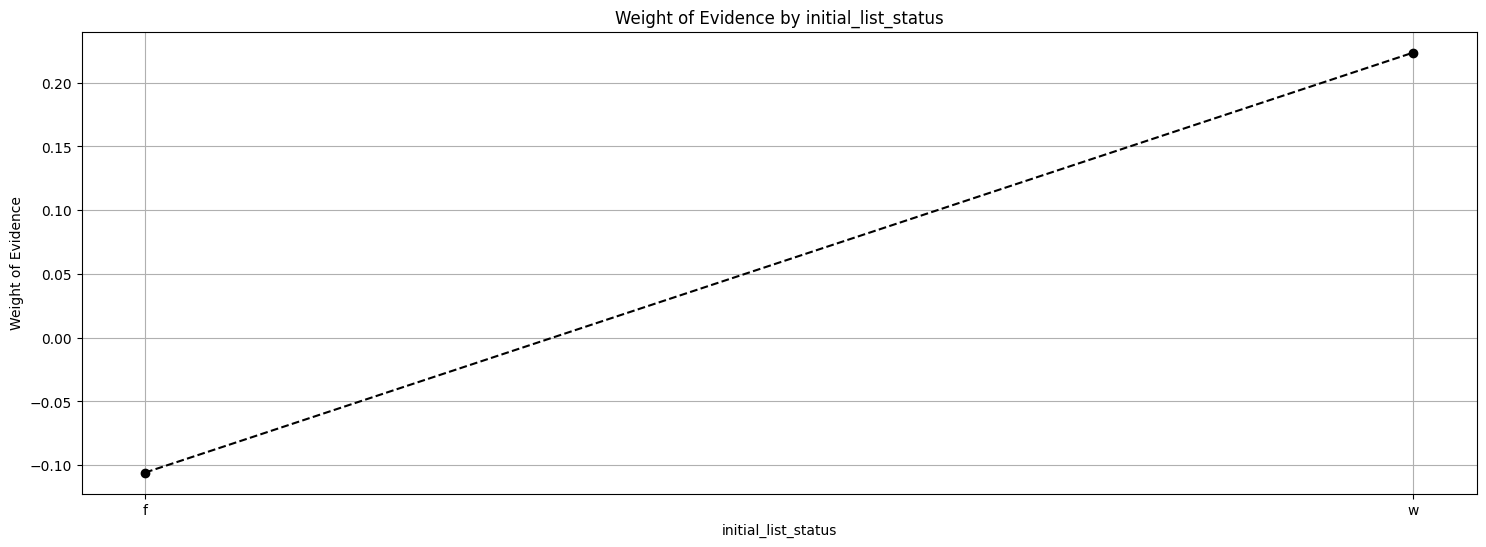

              Variable         IV
0                grade 0.29495460
4              purpose 0.03808774
5  initial_list_status 0.02362604
1       home_ownership 0.02241447
3  verification_status 0.02137440
2           addr_state 0.01281067


In [49]:
print(woe_raw.woe_tables['initial_list_status'].sort_values('WoE'))
woe_raw.plot_woe('initial_list_status')
print(iv_raw)



**initial_list_status:**

- The variable contains two categories (‘f’ and ‘w’) with sufficient observations in both segments.  

- WoE analysis shows clear separation:  
    • ‘f’ has positive WoE indicating lower risk  
    • ‘w’ has negative WoE indicating higher risk  

- The relationship is monotonic and stable, with no sparsity or extreme values observed.  

- Since the variable is already binary, well-distributed, and exhibits strong discriminatory power, no further grouping or transformation is required.  

- The variable is directly suitable for modeling.

- Predictive power remains meaningful:
    - IV: 0.023626

      
- Final variable used:
    - initial_list_status

count       373028
unique           3
top       Verified
freq        134347
Name: verification_status, dtype: object

--- Number of unique values ---
unique values:3

---value counts ---
verification_status
Verified           134347
Source Verified    120036
Not Verified       118645
Name: count, dtype: int64

---plot ---


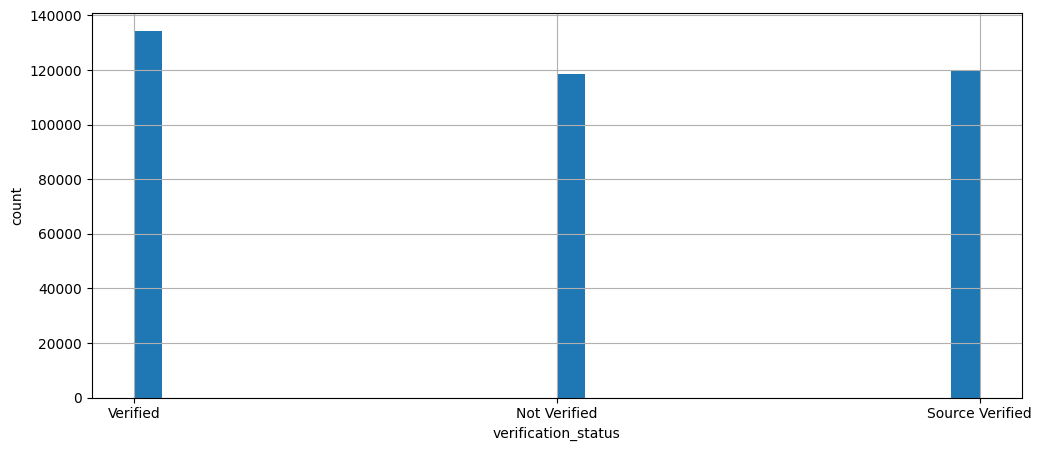

In [50]:
quick_eda(X_train, 'verification_status')

  verification_status   n_obs  n_bad  n_good  prop_n_good  prop_n_bad  \
2            Verified  134347  17138  117209   0.35277077  0.42032913   
1     Source Verified  120036  12509  107527   0.32363042  0.30680090   
0        Not Verified  118645  11127  107518   0.32360333  0.27290675   

          WoE         IV  
2 -0.17521958 0.01183755  
1  0.05340316 0.00089875  
0  0.17038829 0.00863810  


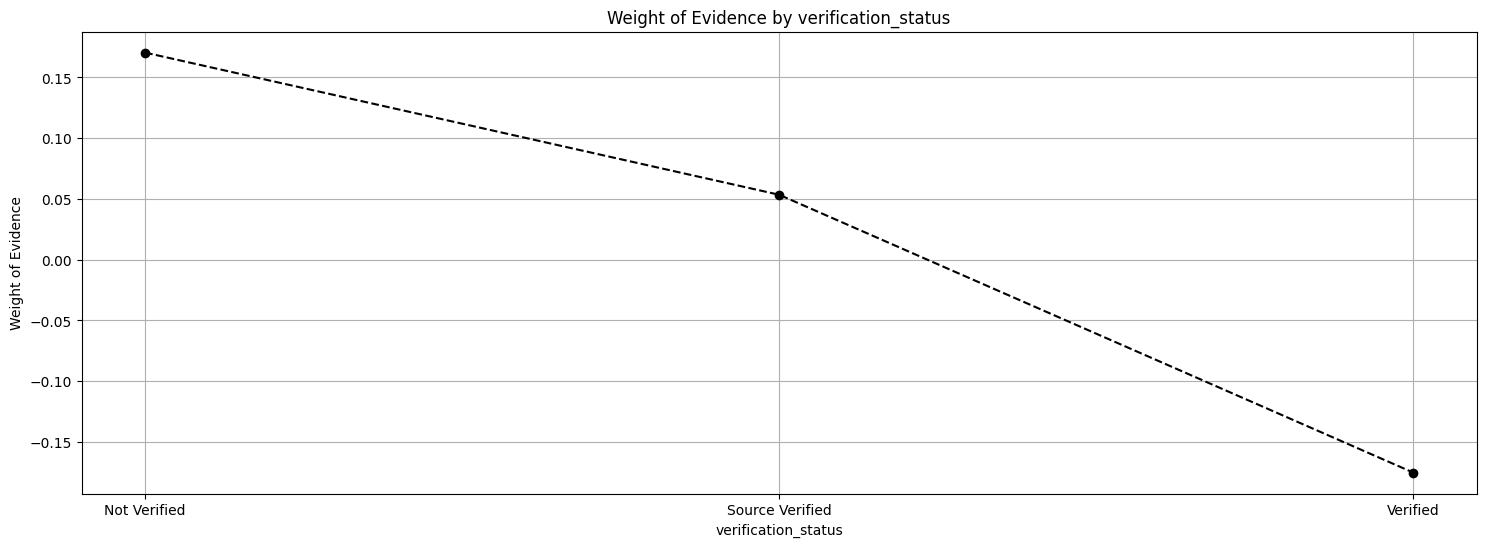

              Variable         IV
0                grade 0.29495460
4              purpose 0.03808774
5  initial_list_status 0.02362604
1       home_ownership 0.02241447
3  verification_status 0.02137440
2           addr_state 0.01281067


In [51]:
print(woe_raw.woe_tables['verification_status'].sort_values('WoE'))
woe_raw.plot_woe('verification_status')
print(iv_raw)

**verification_status**

- The variable contains three categories:
    - Verified
    - Source Verified
    - Not Verified    
 with sufficient observations across all segments, resulting in stable WoE estimation.
- WoE analysis shows a clear and meaningful differentiation in borrower risk behavior:


    - Verified → negative WoE indicating relatively higher default tendency
    - Source Verified → mildly positive WoE indicating moderate risk
    - Not Verified → strongest positive WoE indicating relatively lower observed default risk
  
- The observed pattern differs from intuitive business expectations, suggesting that the variable captures dataset-specific borrower behavior rather than a simple verification-quality hierarchy.
- All categories are well represented with stable WoE values, and no sparsity or extreme WoE behavior is observed.
- The WoE trend is smooth and interpretable, with sufficient separation between categories to provide useful discriminatory power.
- Since the variable already exhibits stable behavior and meaningful differentiation, no grouping or transformation was required.
- Predictive power remains meaningful:
    - IV: 0.021374
 - Final variable used:
    - verification_status





In [52]:

continuous_vars=[
    'term_int',
    'emp_length_int',
    'credit_age_months',
    'int_rate',
    'funded_amnt',
    'delinq_2yrs',
    'inq_last_6mths',
    'open_acc',
    'pub_rec',
    'total_acc',
    'acc_now_delinq',
    'total_rev_hi_lim',
    'installment',
    'annual_inc',
    'mths_since_last_delinq',
    'dti',
    'mths_since_last_record'
]   

In [53]:
train_df['mths_since_last_delinq_missing'] = train_df['mths_since_last_delinq'].isnull().astype(int)
train_df['mths_since_last_record_missing'] = train_df['mths_since_last_record'].isnull().astype(int)

In [54]:
X_train=train_df.drop(columns=['good_bad'])
y_train=train_df['good_bad']

In [55]:
woe_cont=WoeBinner()

In [56]:
woe_cont.fit(X_train, y_train, continuous_vars=continuous_vars)

count   373028.00000000
mean        13.83040453
std          4.35789892
min          5.42000000
25%         10.99000000
50%         13.66000000
75%         16.49000000
max         26.06000000
Name: int_rate, dtype: float64

--- Number of unique values ---
unique values:502

---value counts ---
int_rate
12.99000000    12733
10.99000000    11828
15.61000000    10439
8.90000000      9125
16.29000000     8472
11.99000000     8043
7.90000000      8017
6.03000000      7874
13.98000000     7836
12.49000000     7745
Name: count, dtype: int64

---plot ---


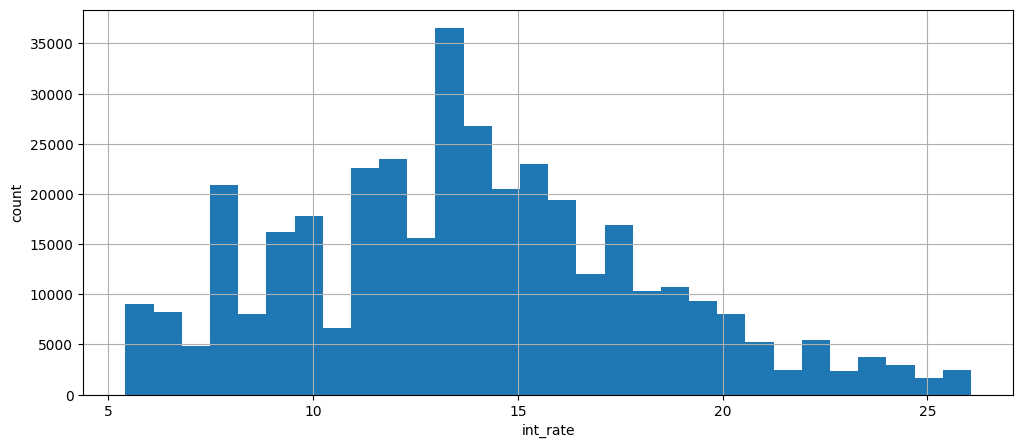

In [57]:
quick_eda(X_train,'int_rate')

In [58]:
train_df['int_rate_bin']=pd.qcut(train_df['int_rate'], q=10,duplicates='drop')

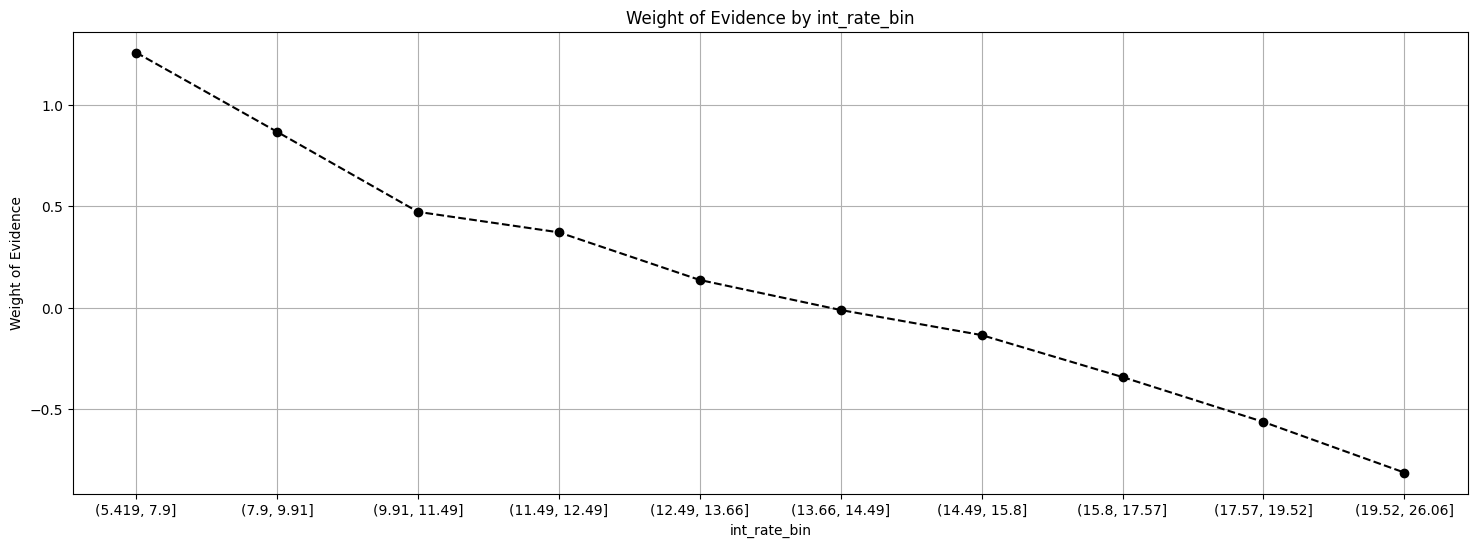

In [59]:
X_train=train_df.drop(columns=['good_bad'])
y_train=train_df['good_bad']
woe_grp.fit(X_train,y_train, discrete_vars=['int_rate_bin'])
woe_grp.plot_woe('int_rate_bin')

In [60]:
INT_RATE_BINS = [0, 10, 13, 16, 20, 30]
train_df['int_rate_bin']=pd.cut(train_df['int_rate'], bins=INT_RATE_BINS)

  int_rate_bin   n_obs  n_bad  n_good  prop_n_good  prop_n_bad         WoE  \
0      (0, 10]   76538   3145   73393   0.22089576  0.07714475  1.05200740   
1     (10, 13]   89454   6893   82561   0.24848911  0.16906607  0.38510942   
2     (13, 16]  101298  11686   89612   0.26971082  0.28661647 -0.06079462   
3     (16, 20]   73574  12004   61570   0.18531154  0.29441556 -0.46295383   
4     (20, 30]   32164   7046   25118   0.07560029  0.17281846 -0.82678153   

          IV  
0 0.15122713  
1 0.03058656  
2 0.00102777  
3 0.05051012  
4 0.08037819  


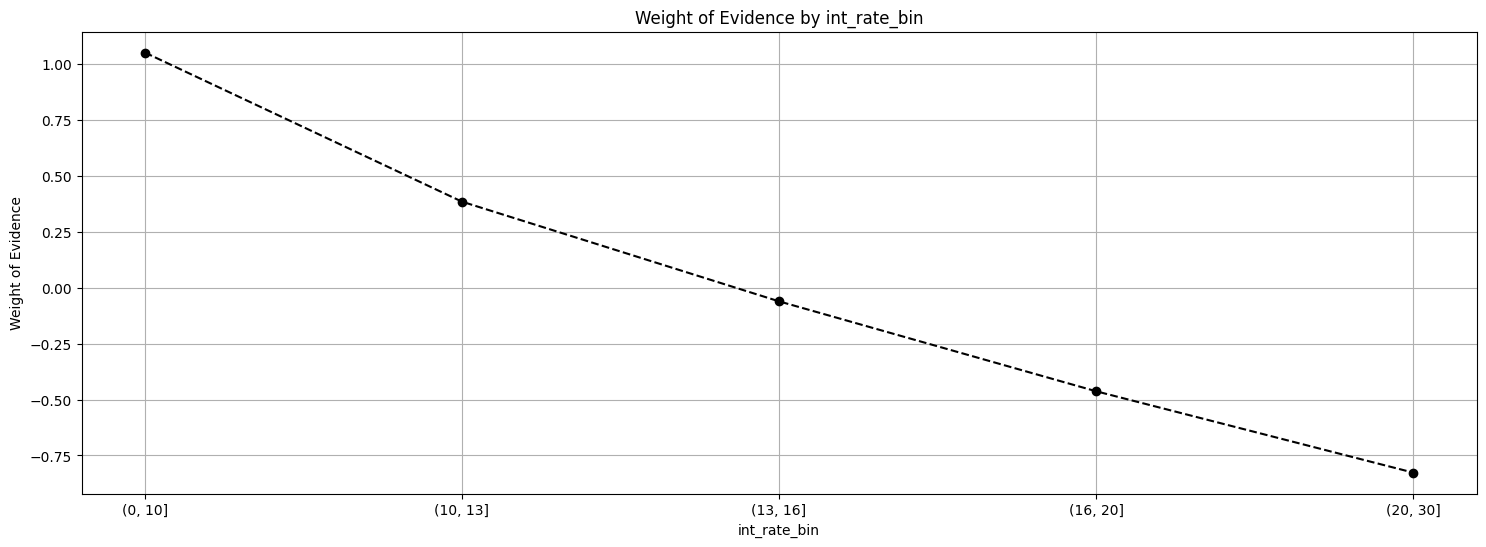

,Variable,IV
0,int_rate_bin,0.31372977


In [61]:
woe_grp.fit(train_df.drop(columns=['good_bad']), y_train, discrete_vars=['int_rate_bin'])
print(woe_grp.woe_tables['int_rate_bin'])
woe_grp.plot_woe('int_rate_bin')
woe_grp.iv_summary()

**int_rate:**

- Interest rate is a continuous variable with a wide distribution (range ~5.4% to 26%) and sufficient variability across observations.  

- Initial exploration using quantile binning (qcut) revealed a clear monotonic relationship between interest rate and default risk, where higher interest rates correspond to higher probability of default.  

- Based on WoE trend and business understanding, manual binning was applied using the following thresholds:  
    • (0–10], (10–13], (13–16], (16–20], (20–30]  

- These bins were selected to ensure:  
    • Adequate observations in each bin  
    • Stable WoE estimates  
    • Preservation of monotonic risk behavior

- Manual binning improved:

    - business interpretability
    - scorecard explainability
    - monotonic stability
    - robustness against overfitting
  
      

- Post-binning WoE shows a strong monotonic decreasing trend:  
    • Lower interest rates → higher WoE → lower risk  
    • Higher interest rates → lower WoE → higher risk  

- The binning aligns with both statistical evidence and business intuition, improving interpretability while maintaining model performance.

- int_rate_bin demonstrated meaningful predictive power with IV = 0.0313, showing a stable monotonic relationship between higher interest rates and increasing borrower default risk.

- The final binned variable `int_rate_bin` is stable, monotonic, and suitable for modeling.  

count   373028.00000000
mean        17.22256973
std          7.85125166
min          0.00000000
25%         11.37000000
50%         16.87000000
75%         22.79000000
max         39.99000000
Name: dti, dtype: float64

--- Number of unique values ---
unique values:3997

---value counts ---
dti
14.40000000    334
19.20000000    319
0.00000000     302
13.20000000    298
12.00000000    291
16.80000000    285
18.00000000    281
15.60000000    278
20.40000000    265
21.60000000    240
Name: count, dtype: int64

---plot ---


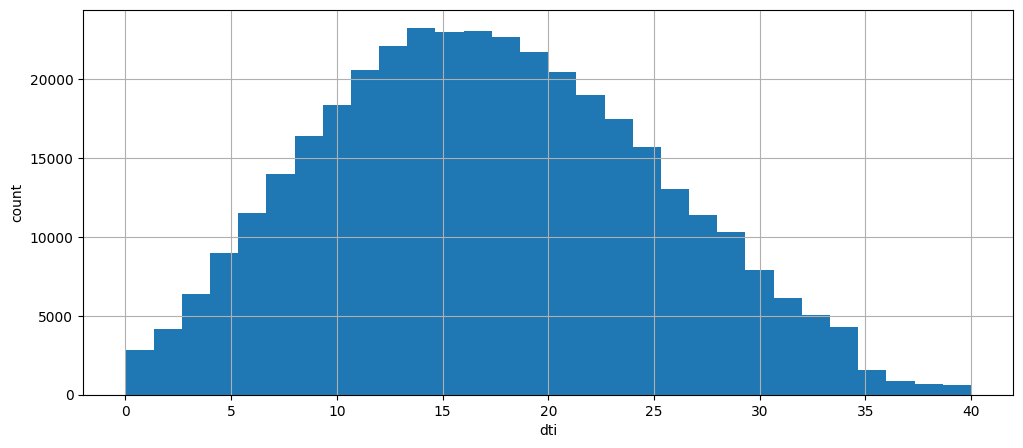

In [62]:
quick_eda(X_train,'dti')

In [63]:
train_df['dti_bin']=pd.qcut(train_df['dti'], q=10, duplicates='drop')

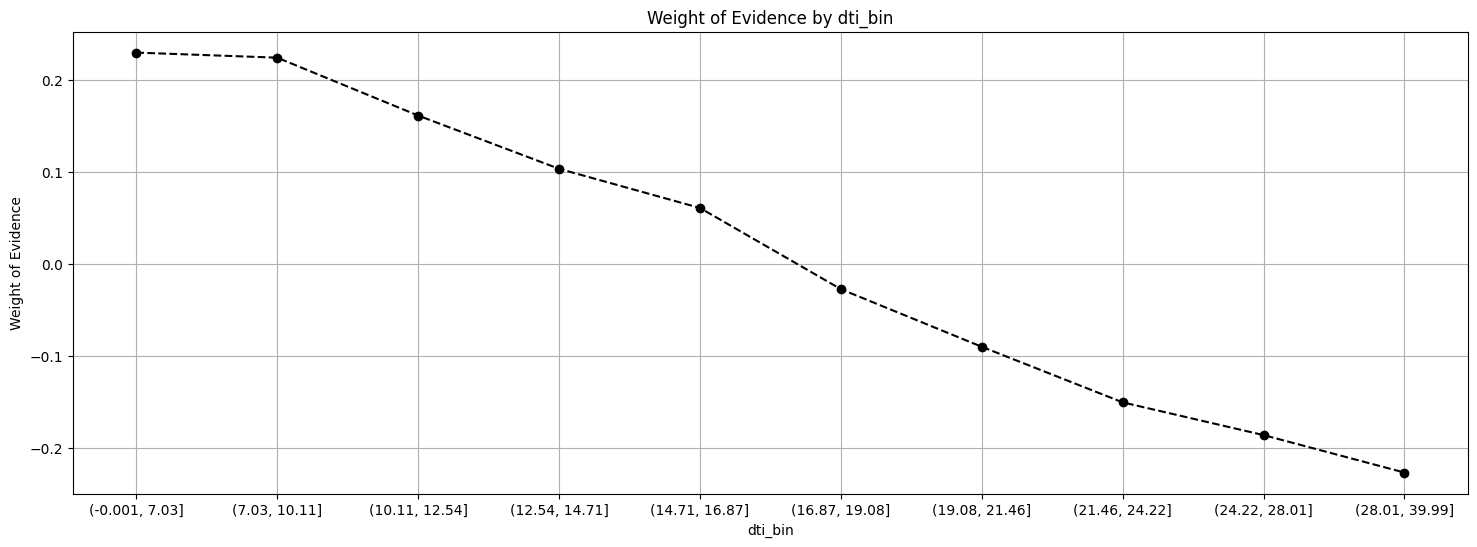

In [64]:
woe_grp.fit(train_df.drop(columns=['good_bad']), y_train, discrete_vars=['dti_bin'])
woe_grp.plot_woe('dti_bin')

In [65]:
DTI_BINS= [0,7,12,17,24,40,100]
train_df['dti_bin']=pd.cut(train_df['dti'], bins=DTI_BINS)

    dti_bin   n_obs  n_bad  n_good  prop_n_good  prop_n_bad         WoE  \
0    (0, 7]   36749   3247   33502   0.10091084  0.07974217  0.23543877   
1   (7, 12]   66331   6054   60277   0.18155819  0.14866789  0.19986128   
2  (12, 17]   85399   8656   76743   0.23115442  0.21255985  0.08386238   
3  (17, 24]  107007  12670   94337   0.28414824  0.31112339 -0.09069351   
4  (24, 40]   77240  10098   67142   0.20223584  0.24796808 -0.20386550   

          IV  
0 0.00498392  
1 0.00657350  
2 0.00155939  
3 0.00244647  
4 0.00932323  


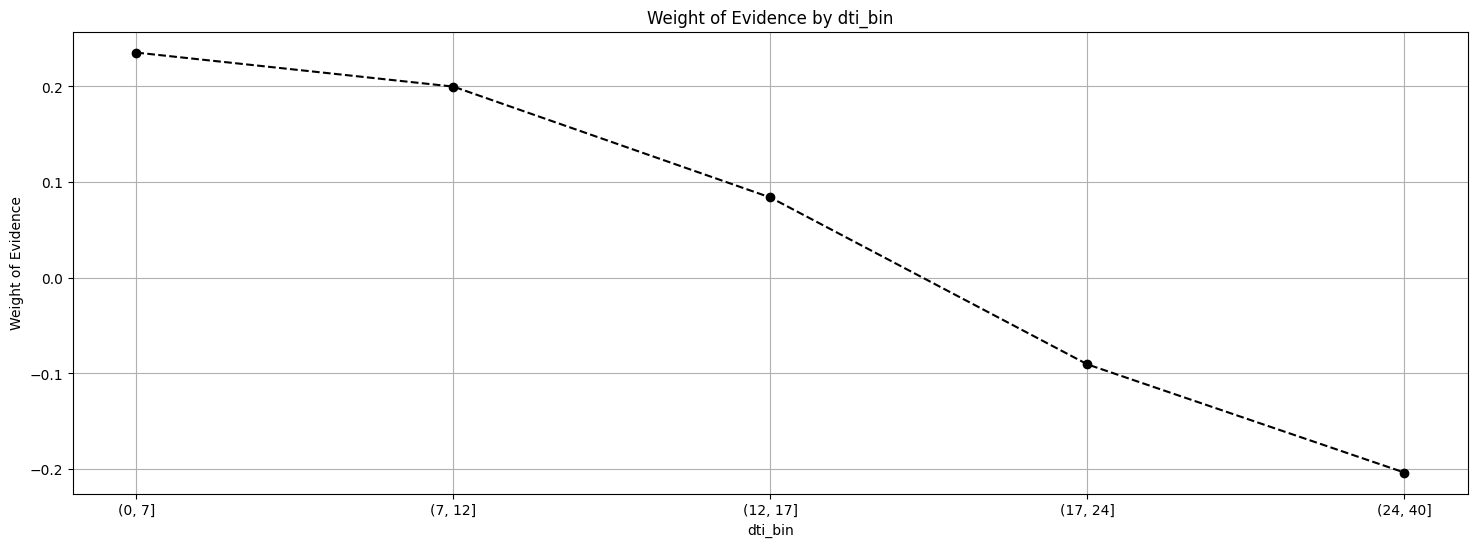

,Variable,IV
0,dti_bin,0.02488650


In [66]:
woe_grp.fit(train_df.drop(columns=['good_bad']), y_train, discrete_vars=['dti_bin'])
print(woe_grp.woe_tables['dti_bin'])
woe_grp.plot_woe('dti_bin')
woe_grp.iv_summary()


**dti**

- Debt-to-income ratio (DTI) is a continuous variable reflecting borrower leverage and repayment capacity.
- Initial quantile-based binning revealed a clear monotonic relationship, where increasing DTI levels corresponded to higher default risk.
- Based on WoE trend analysis and business interpretability, manual binning was applied using the following thresholds:
- (0–7]
(7–12]
(12–17]
(17–24]
(24–40]

- The selected bins ensure:
    - adequate observations in each segment
    - stable WoE estimation
    - meaningful separation of borrower risk levels
    - smooth monotonic risk progression
- Post-binning WoE exhibited a strong monotonic decreasing trend:
    - lower DTI → higher WoE → lower risk
    - higher DTI → lower WoE → higher risk
- The variable demonstrates moderate predictive power:
    - IV: ~0.024
- The binning structure aligns with financial intuition, where higher borrower leverage is associated with increased credit risk.
- Final variable used:
    - dti_bin'

count   373028.00000000
mean       193.47476061
std         88.90187119
min          0.00000000
25%        133.00000000
50%        176.00000000
75%        238.00000000
max        854.00000000
Name: credit_age_months, dtype: float64

--- Number of unique values ---
unique values:688

---value counts ---
credit_age_months
154    2415
158    2382
160    2357
157    2355
155    2333
138    2330
149    2330
161    2327
147    2318
159    2314
Name: count, dtype: int64

---plot ---


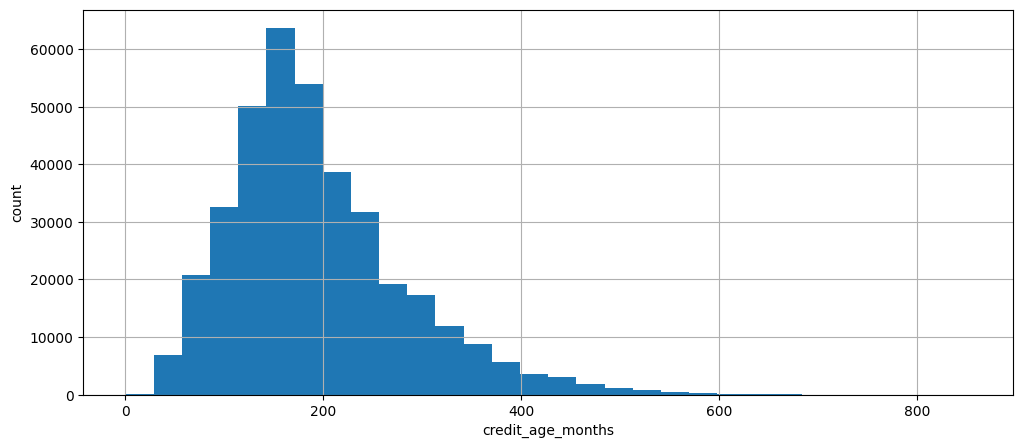

In [67]:
quick_eda(X_train,'credit_age_months')

In [68]:
train_df['credit_age_months_bin']=pd.qcut(train_df['credit_age_months'], q=10, duplicates='drop')


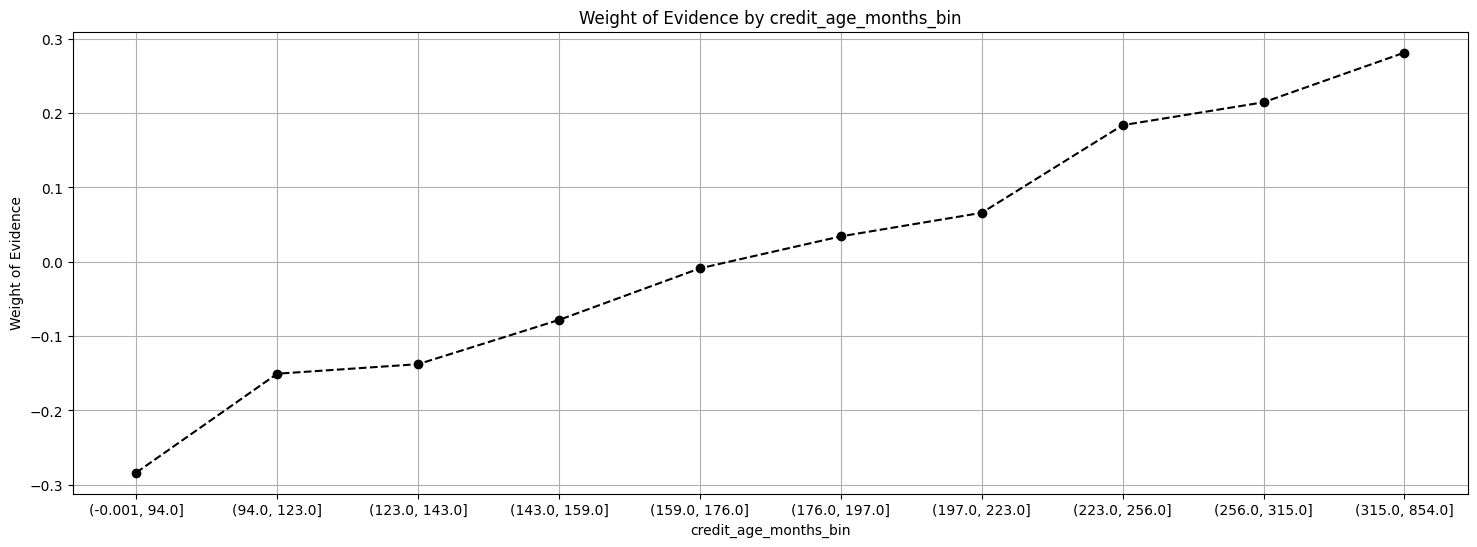

In [69]:
woe_grp.fit(train_df.drop(columns=['good_bad']), y_train, discrete_vars=['credit_age_months_bin'])
woe_grp.plot_woe('credit_age_months_bin')

In [70]:
CREDIT_AGE_MONTHS_BINS=[0, 125, 160, 200, 260, 320, 900]
train_df['credit_age_months_bin']=pd.cut(train_df['credit_age_months'], bins=CREDIT_AGE_MONTHS_BINS)

  credit_age_months_bin  n_obs  n_bad  n_good  prop_n_good  prop_n_bad  \
0              (0, 125]  79167  10439   68728   0.20686775  0.25604582   
1            (125, 160]  72531   8722   63809   0.19206192  0.21393358   
2            (160, 200]  78050   8394   69656   0.20966096  0.20588885   
3            (200, 260]  72027   6995   65032   0.19574306  0.17157608   
4            (260, 320]  36762   3305   33457   0.10070462  0.08107280   
5            (320, 900]  34469   2917   31552   0.09497071  0.07155646   

          WoE         IV  
0 -0.21327670 0.01048854  
1 -0.10784778 0.00235881  
2  0.01815532 0.00006848  
3  0.13177609 0.00318463  
4  0.21684426 0.00425705  
5  0.28308177 0.00662815  


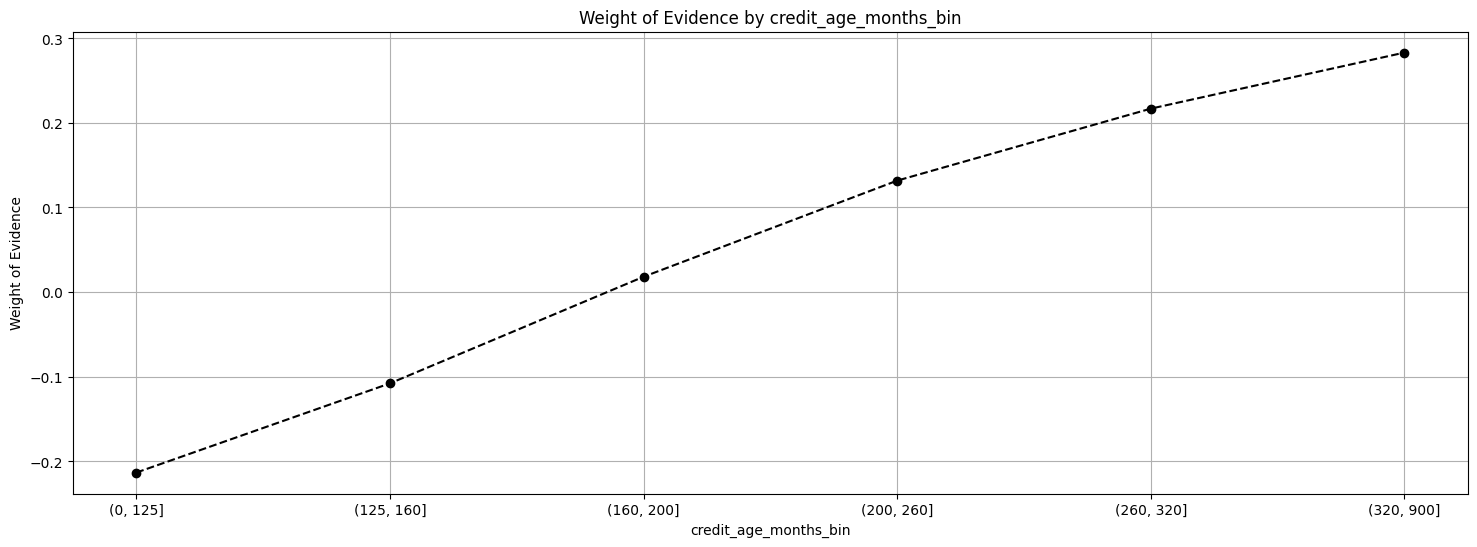

,Variable,IV
0,credit_age_months_bin,0.02698566


In [71]:
woe_grp.fit(train_df.drop(columns=['good_bad']), y_train, discrete_vars=['credit_age_months_bin'])
print(woe_grp.woe_tables['credit_age_months_bin'])
woe_grp.plot_woe('credit_age_months_bin')
woe_grp.iv_summary()

**credit_age_months**
- Credit age in months represents the length of a borrower’s credit history and serves as an indicator of borrower maturity and repayment stability.
- Initial quantile-based binning revealed a clear monotonic increasing WoE trend, where longer credit history corresponded to lower observed default risk.
- Based on WoE behavior and business interpretability, manual binning was applied using the following thresholds: 
    - (0–125]
(125–160]
(160–200]
(200–260]
(260–320]
(320–900]
- The selected bins preserve meaningful separation of borrower maturity levels while maintaining sufficient observations and stable WoE estimation across segments.
- Post-binning WoE exhibited a strong monotonic increasing relationship:
    - shorter credit history → lower WoE → higher risk
    - longer credit history → higher WoE → lower risk
- The binning structure improves:
    - interpretability
    - monotonic stability
    - risk granularity
    - scorecard explainability
      
- credit_age_months_bin demonstrated moderate predictive strength with IV = 0.0269, reflecting stable risk differentiation across borrower credit history segments.
  
- The variable provides meaningful discriminatory power and aligns with expected credit risk behavior, where borrowers with longer credit history generally exhibit lower default tendency.


- Final variable used:
    - credit_age_months_bin

count    373028.00000000
mean      73267.47346061
std       55198.40344275
min        1896.00000000
25%       45000.00000000
50%       62853.00000000
75%       88877.00000000
max     7446395.00000000
Name: annual_inc, dtype: float64

--- Number of unique values ---
unique values:27062

---value counts ---
annual_inc
60000.00000000    14373
50000.00000000    12749
65000.00000000    10565
40000.00000000    10290
70000.00000000     9984
45000.00000000     9606
80000.00000000     9297
75000.00000000     9187
55000.00000000     8752
90000.00000000     7093
Name: count, dtype: int64

---plot ---


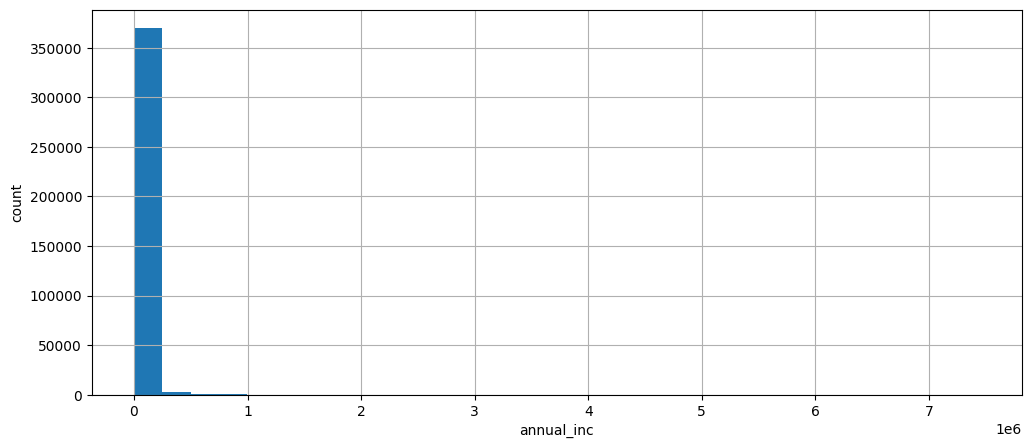

In [72]:
quick_eda(X_train, 'annual_inc')

In [73]:
train_df['annual_inc'] = np.clip(train_df['annual_inc'], 0, 200000)

In [74]:
train_df['annual_inc_bin']=pd.qcut(train_df['annual_inc'], q=10, duplicates='drop')


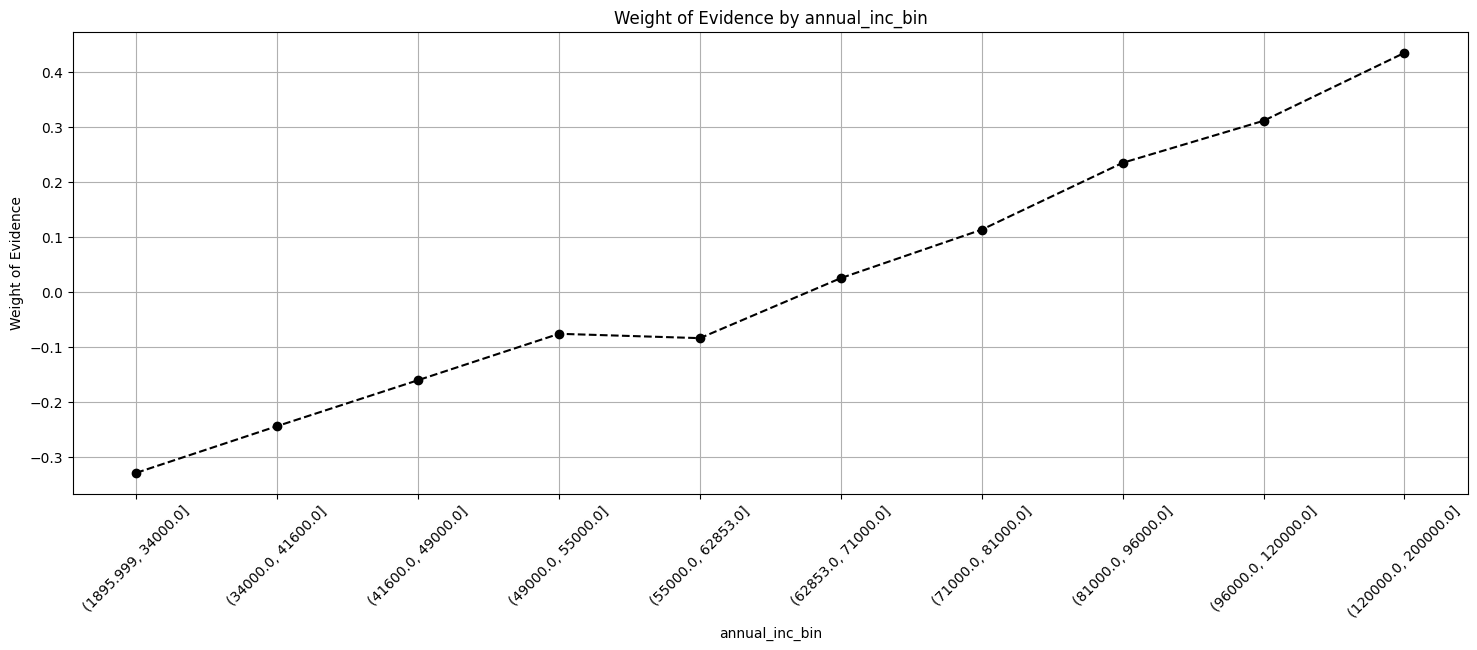

In [75]:
woe_grp.fit(train_df.drop(columns=['good_bad']), y_train, discrete_vars=['annual_inc_bin'])
woe_grp.plot_woe('annual_inc_bin',45)

In [76]:
ANNUAL_INC_BINS=ANNUAL_INC_BINS = [0, 55000, 80000, 120000, 200000]
train_df['annual_inc_bin']=pd.cut(train_df['annual_inc'], bins=ANNUAL_INC_BINS)

     annual_inc_bin   n_obs  n_bad  n_good  prop_n_good  prop_n_bad  \
0        (0, 55000]  151914  19874  132040   0.39740831  0.48743072   
1    (55000, 80000]  108464  11693   96771   0.29125759  0.28678815   
2   (80000, 120000]   76899   6575   70324   0.21165885  0.16126698   
3  (120000, 200000]   35751   2632   33119   0.09968127  0.06456320   

          WoE         IV  
0 -0.20418392 0.01838113  
1  0.01546428 0.00006912  
2  0.27191451 0.01370228  
3  0.43433315 0.01525294  


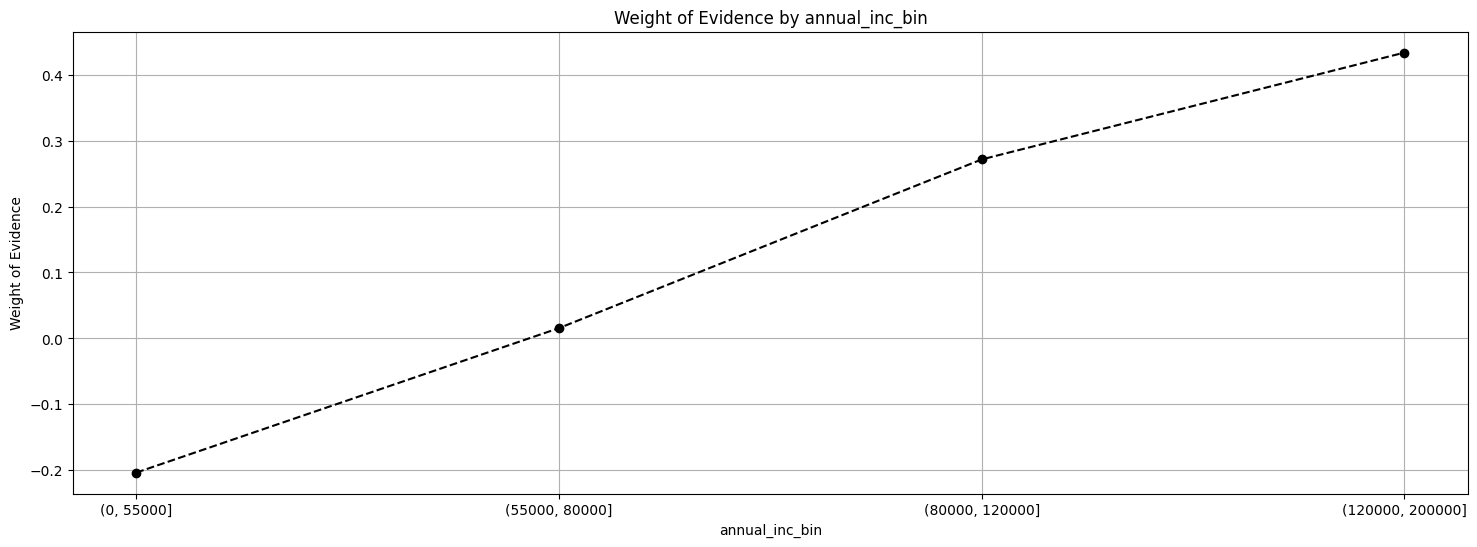

,Variable,IV
0,annual_inc_bin,0.04740547


In [77]:
woe_grp.fit(train_df.drop(columns=['good_bad']), y_train, discrete_vars=['annual_inc_bin'])
print(woe_grp.woe_tables['annual_inc_bin'])
woe_grp.plot_woe('annual_inc_bin')
woe_grp.iv_summary()


**annual_inc**
- Annual income is a continuous variable representing borrower repayment capacity and financial strength.
- Initial quantile-based binning revealed a clear monotonic increasing WoE trend, where higher income levels corresponded to lower observed default risk.
- Prior to binning, extreme income outliers were capped to improve statistical stability and reduce sensitivity to unusually large observations.
- Based on WoE behavior and business interpretability, manual binning was applied using the following thresholds:
    - (0–55k]
(55k–80k]
(80k–120k]
(120k–200k]
- The selected bins preserved a stable monotonic WoE structure:
   - lower income → lower WoE → higher risk
    - higher income → higher WoE → lower risk
- All bins maintained sufficient observations and stable WoE estimates suitable for scorecard modeling.
- The variable aligns with expected financial intuition, where stronger borrower income is associated with lower default tendency.

- annual_inc_bin demonstrated meaningful predictive contribution with IV = 0.0470, showing a clear monotonic relationship between higher income levels and lower default risk.

 - Final variable used:
     - `annual_inc_bin`

count   373028.00000000
mean       431.99000421
std        243.41466106
min         15.67000000
25%        256.42000000
50%        380.24500000
75%        566.36250000
max       1409.99000000
Name: installment, dtype: float64

--- Number of unique values ---
unique values:51337

---value counts ---
installment
327.34000000    971
336.90000000    950
332.10000000    785
491.01000000    718
392.81000000    680
317.54000000    675
332.72000000    651
334.49000000    627
304.36000000    616
337.47000000    589
Name: count, dtype: int64

---plot ---


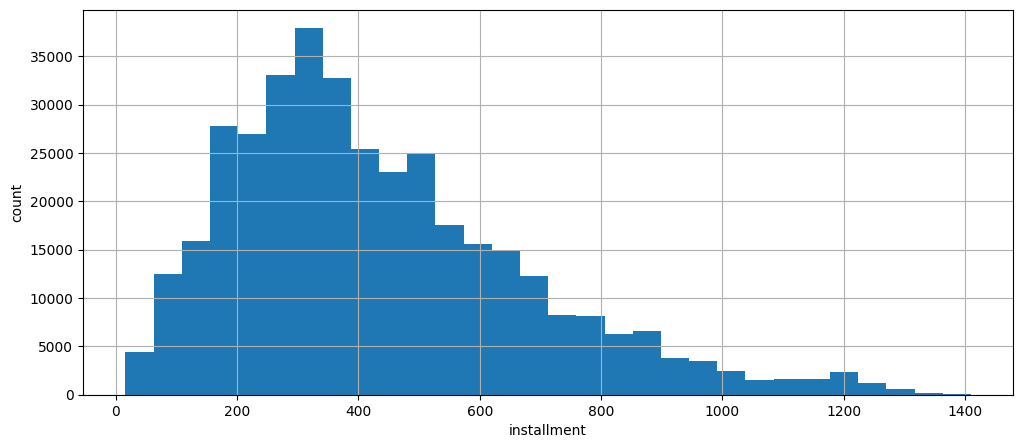

In [78]:
quick_eda(X_train,'installment')

In [79]:
train_df['installment_bin'] = pd.qcut(train_df['installment'], q=10, duplicates='drop')

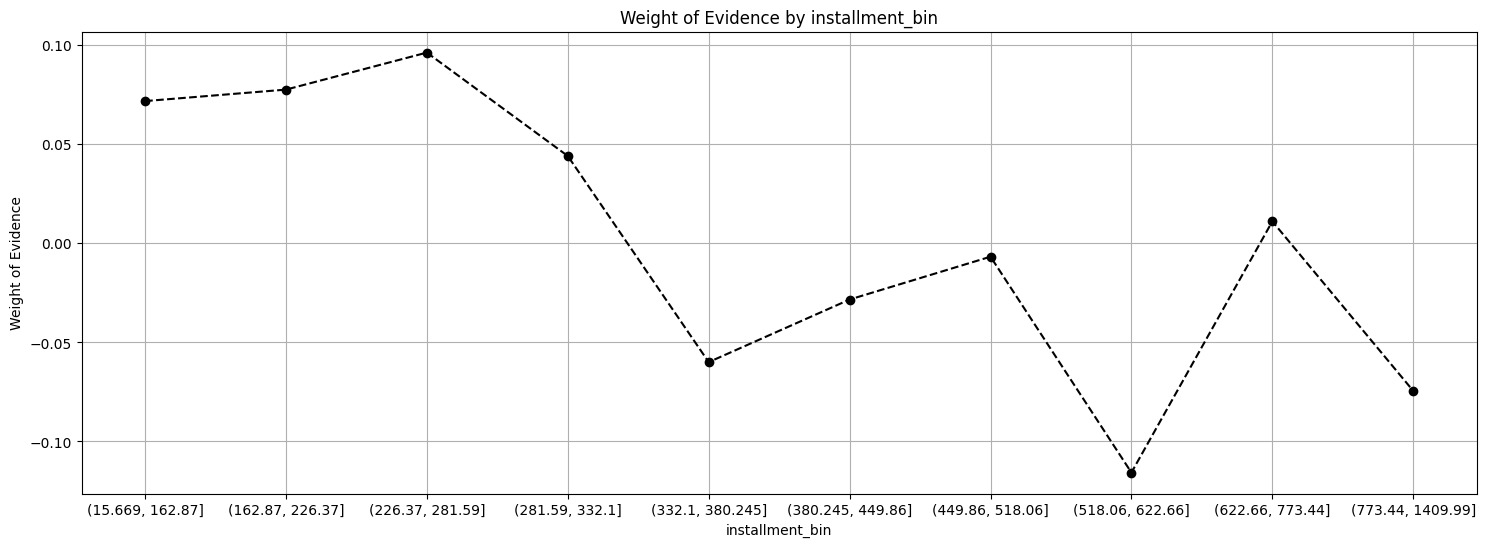

In [80]:

woe_grp.fit(train_df.drop(columns=['good_bad']), y_train, discrete_vars=['installment_bin'])
woe_grp.plot_woe('installment_bin')

In [81]:
INSTALLMENT_BINS = [0, 250, 450, 700, 1500]
train_df['installment_bin'] = pd.cut(train_df['installment'], bins=INSTALLMENT_BINS)

  installment_bin   n_obs  n_bad  n_good  prop_n_good  prop_n_bad         WoE  \
0        (0, 250]   89075   9008   80067   0.24098280  0.22093736  0.08684634   
1      (250, 450]  134950  14781  120169   0.36167962  0.36252269 -0.00232827   
2      (450, 700]   98735  11147   87588   0.26361910  0.27339726 -0.03642066   
3     (700, 1500]   50268   5838   44430   0.13372450  0.14319174 -0.06840286   

          IV  
0 0.00174087  
1 0.00000196  
2 0.00035613  
3 0.00064759  


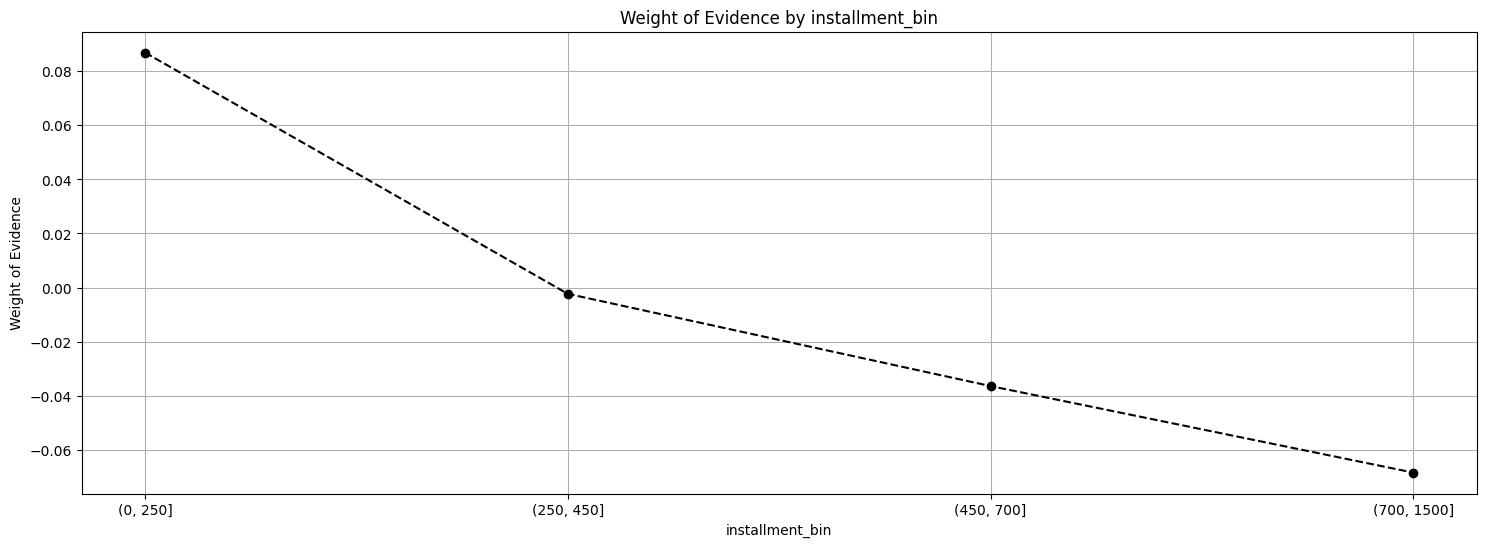

,Variable,IV
0,installment_bin,0.00274655


In [82]:
woe_grp.fit(train_df.drop(columns=['good_bad']), y_train, discrete_vars=['installment_bin'])
print(woe_grp.woe_tables['installment_bin'])
woe_grp.plot_woe('installment_bin')
woe_grp.iv_summary()


**installment:**

- Installment amount represents the borrower’s monthly repayment obligation.  

- Initial quantile binning showed a general trend where higher installment amounts correspond to higher default risk, though some fluctuations were observed.  

- To improve stability and interpretability, manual binning was applied using thresholds:  
    • [(0–200),(200–400),(400-700),(700-1500)]   

- Post-binning WoE shows a clear monotonic decreasing trend:  
    • Lower installment → higher WoE → lower risk  
    • Higher installment → lower WoE → higher risk  

- This aligns with financial intuition, where higher repayment burden increases default probability.  

- installment_bin demonstrated very weak predictive power with IV = 0.00027, indicating limited standalone discriminatory ability and minimal incremental model contribution.

- While the current binning provides stability and simplicity, further granularity could be explored to capture additional risk differentiation.  

- The final variable `installment_bin` is stable and suitable for modeling.  

count   373028.00000000
mean         0.80462593
std          1.09054310
min          0.00000000
25%          0.00000000
50%          0.00000000
75%          1.00000000
max         33.00000000
Name: inq_last_6mths, dtype: float64

--- Number of unique values ---
unique values:25

---value counts ---
inq_last_6mths
0.00000000    193144
1.00000000    104227
2.00000000     46258
3.00000000     20081
4.00000000      5791
5.00000000      2221
6.00000000       937
7.00000000       155
8.00000000       100
9.00000000        38
Name: count, dtype: int64

---plot ---


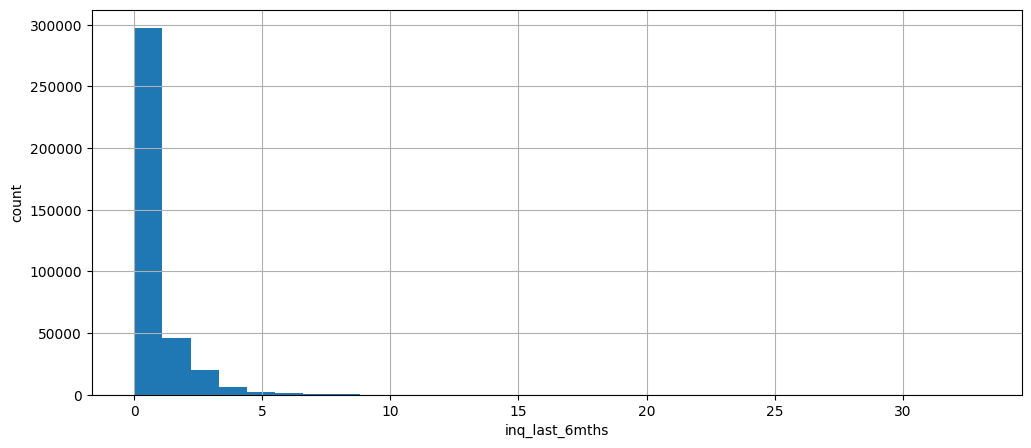

In [83]:
quick_eda(X_train,'inq_last_6mths')

In [84]:
train_df['inq_last_6mths_bin'] = pd.qcut(train_df['inq_last_6mths'], q=10, duplicates='drop')


  inq_last_6mths_bin   n_obs  n_bad  n_good  prop_n_good  prop_n_bad  \
0      (-0.001, 1.0]  297371  29746  267625   0.80548466  0.72954579   
1         (1.0, 2.0]   46258   6240   40018   0.12044550  0.15305096   
2        (2.0, 33.0]   29399   4788   24611   0.07407435  0.11744004   

          WoE         IV  
0  0.09902202 0.00751962  
1 -0.23957357 0.00781141  
2 -0.46085851 0.01998544  


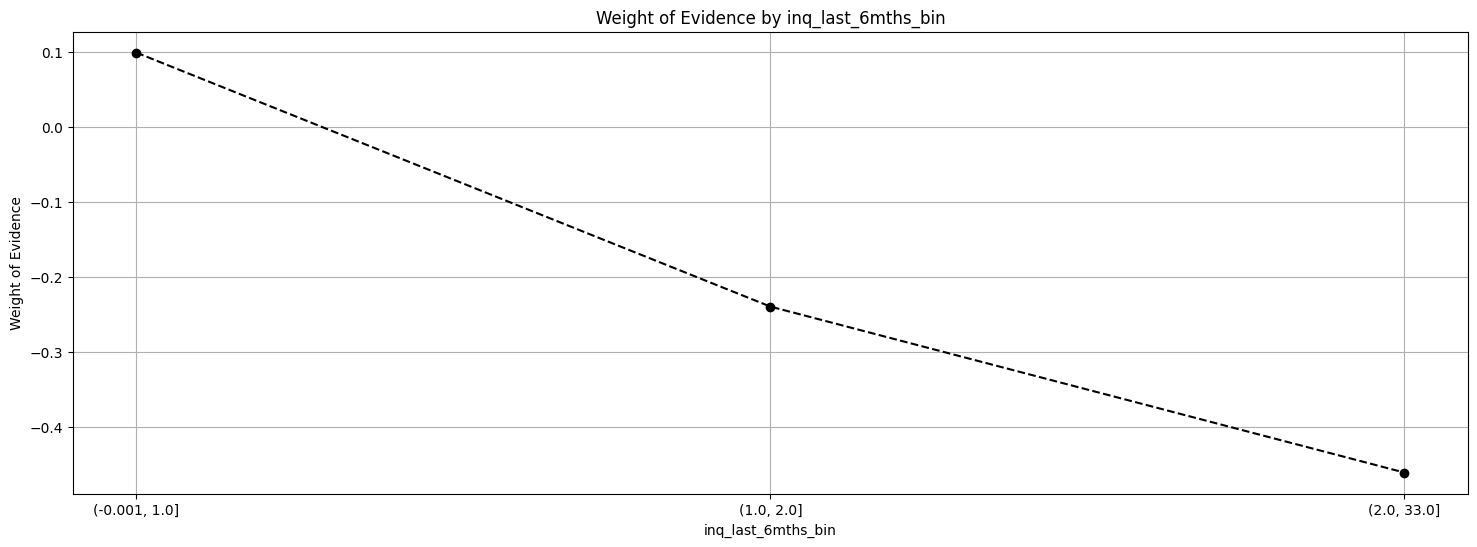

In [85]:
woe_grp.fit(train_df.drop(columns=['good_bad']), y_train, discrete_vars=['inq_last_6mths_bin'])
print(woe_grp.woe_tables['inq_last_6mths_bin'])
woe_grp.plot_woe('inq_last_6mths_bin')

In [86]:
INQ_LAST_6MTHS_BINS= [-1,0,1,3,35]
train_df['inq_last_6mths_bin']=pd.cut(train_df['inq_last_6mths'],bins=INQ_LAST_6MTHS_BINS)

  inq_last_6mths_bin   n_obs  n_bad  n_good  prop_n_good  prop_n_bad  \
0            (-1, 0]  193144  17700  175444   0.52804330  0.43411242   
1             (0, 1]  104227  12046   92181   0.27744286  0.29544563   
2             (1, 3]   66339   9410   56929   0.17134331  0.23079659   
3            (3, 35]    9318   1618    7700   0.02317655  0.03969441   

          WoE         IV  
0  0.19587475 0.01839869  
1 -0.06286981 0.00113183  
2 -0.29786754 0.01770920  
3 -0.53806965 0.00888776  


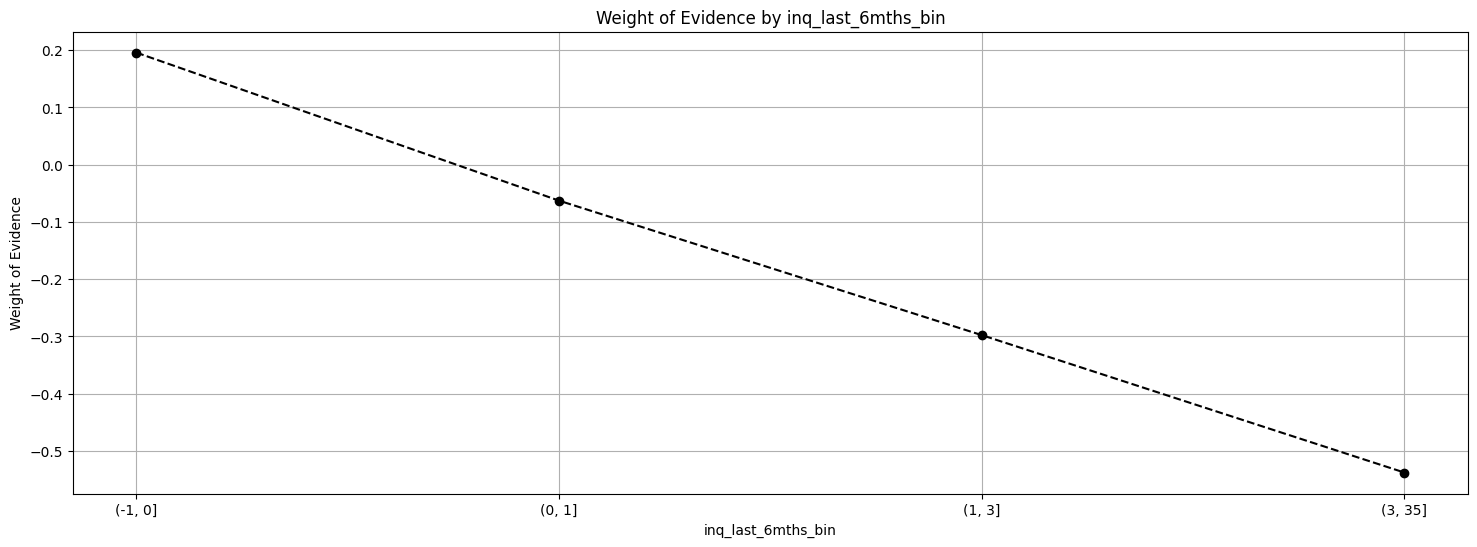

,Variable,IV
0,inq_last_6mths_bin,0.04612748


In [87]:
woe_grp.fit(train_df.drop(columns=['good_bad']), y_train, discrete_vars=['inq_last_6mths_bin'])
print(woe_grp.woe_tables['inq_last_6mths_bin'])
woe_grp.plot_woe('inq_last_6mths_bin')
woe_grp.iv_summary()

**inq_last_6mths**

- Number of inquiries in the last six months captures recent borrower credit-seeking behavior and potential liquidity stress.

- The variable exhibited a highly right-skewed distribution, with a large proportion of borrowers having zero or very few recent inquiries.

- Initial WoE analysis showed a strong monotonic decreasing relationship:
    - fewer inquiries → higher WoE → lower risk
    - more inquiries → lower WoE → higher risk

- Based on WoE behavior and business interpretability, manual binning was applied using the following thresholds:
    - 0 inquiries
    - 1 inquiry
    - 2–3 inquiries
    - 3+ inquiries
- Very high inquiry counts were consolidated into a broader high-risk segment to avoid sparse unstable bins and improve statistical robustness.

- The final grouped structure achieved:
    - strong monotonicity
    - stable WoE estimation
    - meaningful behavioral segmentation
    - improved model robustness
- The variable demonstrated meaningful predictive contribution:
    - IV = 0.0461
- The observed risk behavior aligns with financial intuition, where increasing recent credit inquiries indicate higher borrower risk and potential credit-seeking stress.
- Final variable used:  
    - `inq_last_6mths_bin`





count   373028.00000000
mean         0.28373205
std          0.79639044
min          0.00000000
25%          0.00000000
50%          0.00000000
75%          0.00000000
max         29.00000000
Name: delinq_2yrs, dtype: float64

--- Number of unique values ---
unique values:24

---value counts ---
delinq_2yrs
0.00000000    306520
1.00000000     44979
2.00000000     12983
3.00000000      4503
4.00000000      1888
5.00000000       969
6.00000000       504
7.00000000       287
8.00000000       140
9.00000000        86
Name: count, dtype: int64

---plot ---


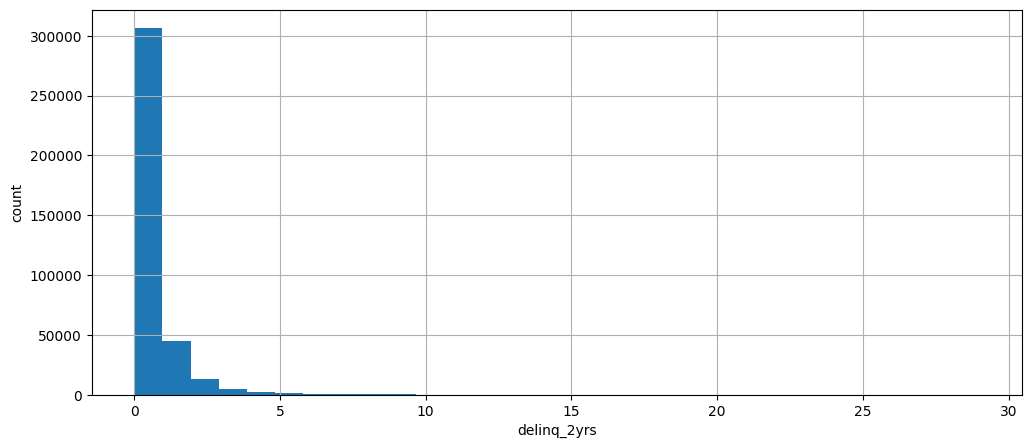

In [88]:
quick_eda(X_train,'delinq_2yrs')

(array([3.0652e+05, 0.0000e+00, 4.4979e+04, 0.0000e+00, 1.2983e+04,
        0.0000e+00, 4.5030e+03, 0.0000e+00, 1.8880e+03, 0.0000e+00,
        9.6900e+02, 0.0000e+00, 5.0400e+02, 0.0000e+00, 2.8700e+02,
        0.0000e+00, 1.4000e+02, 0.0000e+00, 8.6000e+01, 1.6900e+02]),
 array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
         5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. ]),
 <BarContainer object of 20 artists>)

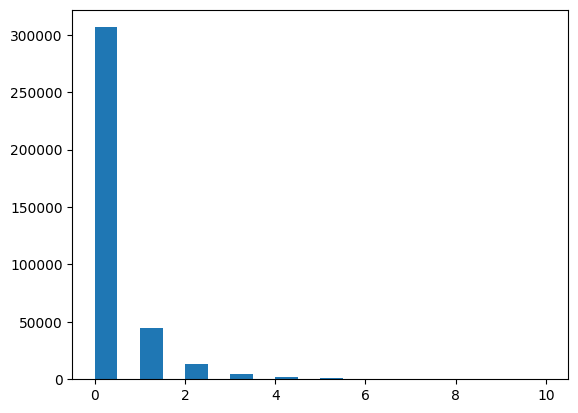

In [89]:
capped = np.clip(X_train['delinq_2yrs'], 0, 10)
plt.hist(capped, bins=20)

In [90]:
train_df['delinq_2yrs_bin'] = pd.qcut(train_df['delinq_2yrs'], q=10, duplicates='drop')


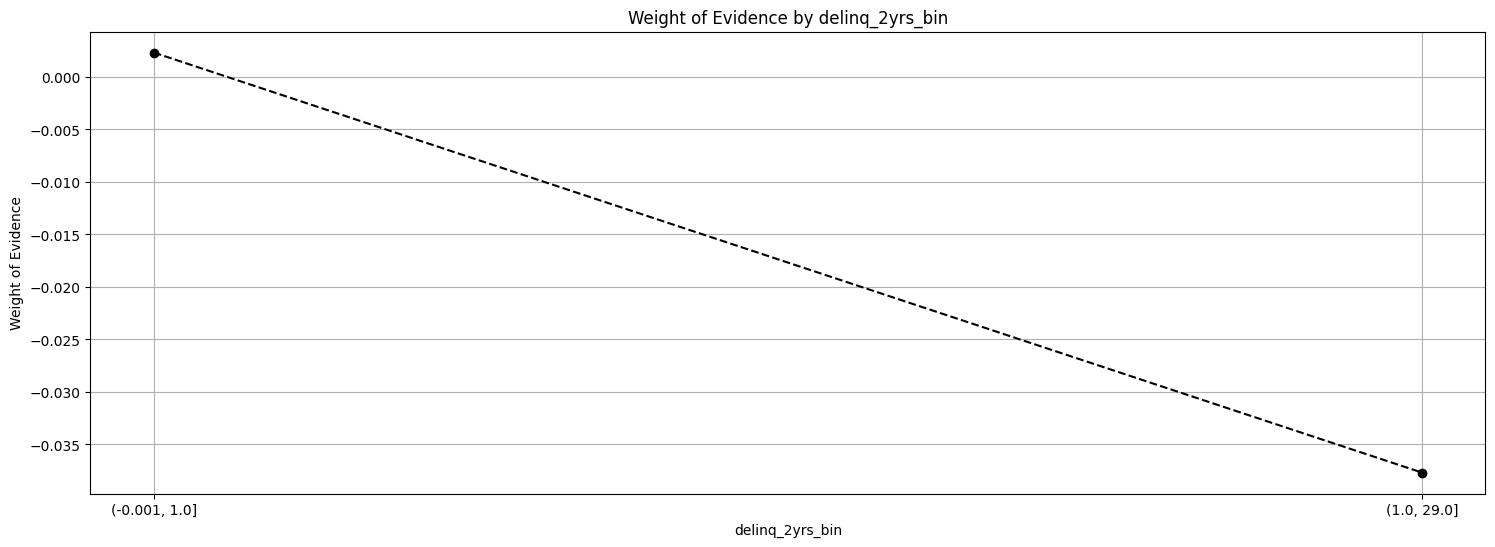

In [91]:
woe_grp.fit(train_df.drop(columns=['good_bad']), y_train, discrete_vars=['delinq_2yrs_bin'])
woe_grp.plot_woe('delinq_2yrs_bin')

In [92]:
DELINQ_2YRS_BINS=[-1,0, 3,50]
train_df['delinq_2yrs_bin']=pd.cut(train_df['delinq_2yrs'], bins=DELINQ_2YRS_BINS)

  delinq_2yrs_bin   n_obs  n_bad  n_good  prop_n_good  prop_n_bad         WoE  \
0         (-1, 0]  306520  33518  273002   0.82166806  0.82205572 -0.00047169   
1          (0, 3]   62465   6803   55662   0.16752996  0.16685878  0.00401437   
2         (3, 50]    4043    453    3590   0.01080649  0.01112228 -0.02880364   

          IV  
0 0.00000018  
1 0.00000269  
2 0.00000910  


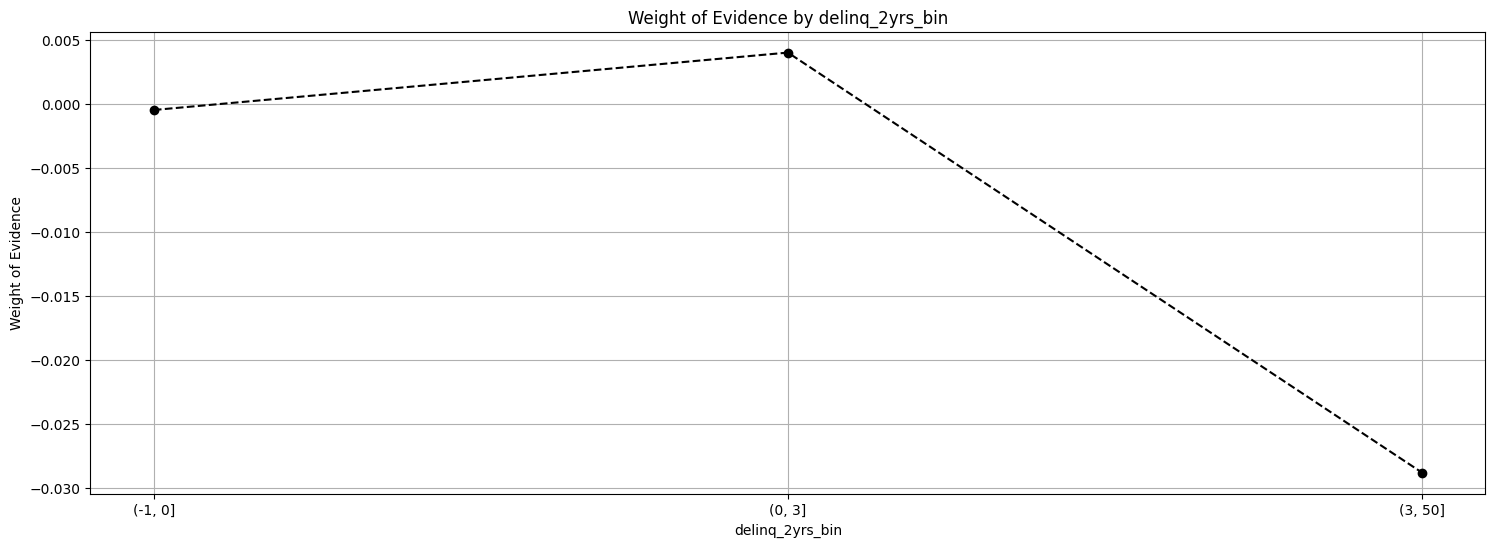

,Variable,IV
0,delinq_2yrs_bin,0.00001197


In [93]:
woe_grp.fit(train_df.drop(columns=['good_bad']), y_train, discrete_vars=['delinq_2yrs_bin'])
print(woe_grp.woe_tables['delinq_2yrs_bin'])
woe_grp.plot_woe('delinq_2yrs_bin')
woe_grp.iv_summary()


**delinq_2yrs**
- The variable represents the number of delinquency events observed over the previous two years and was evaluated as a potential indicator of historical repayment stress.
- Exploratory analysis showed a highly skewed distribution, with the majority of borrowers having zero delinquencies and relatively few observations in higher delinquency ranges.
- Multiple binning strategies were evaluated to improve monotonicity and behavioral separation; however, the variable consistently demonstrated:
    - very weak discriminatory power
    - unstable WoE behavior
    - limited risk differentiation across segments
- The observed WoE pattern did not produce a stable or economically intuitive monotonic relationship, indicating limited standalone predictive contribution.
- The variable exhibited negligible predictive strength:
    - IV ≈ 0.00001
- Based on weak predictive performance, instability across bins, and lack of meaningful incremental model contribution, the variable was excluded from final model development.
- Final decision:
    - `delinq_2yrs` was not retained for modeling.

count   373028.00000000
mean        11.18996965
std          4.99288902
min          0.00000000
25%          8.00000000
50%         10.00000000
75%         14.00000000
max         84.00000000
Name: open_acc, dtype: float64

--- Number of unique values ---
unique values:61

---value counts ---
open_acc
9.00000000     35192
10.00000000    33993
8.00000000     33514
11.00000000    31334
7.00000000     30054
12.00000000    27707
6.00000000     24605
13.00000000    23801
14.00000000    19798
5.00000000     17264
Name: count, dtype: int64

---plot ---


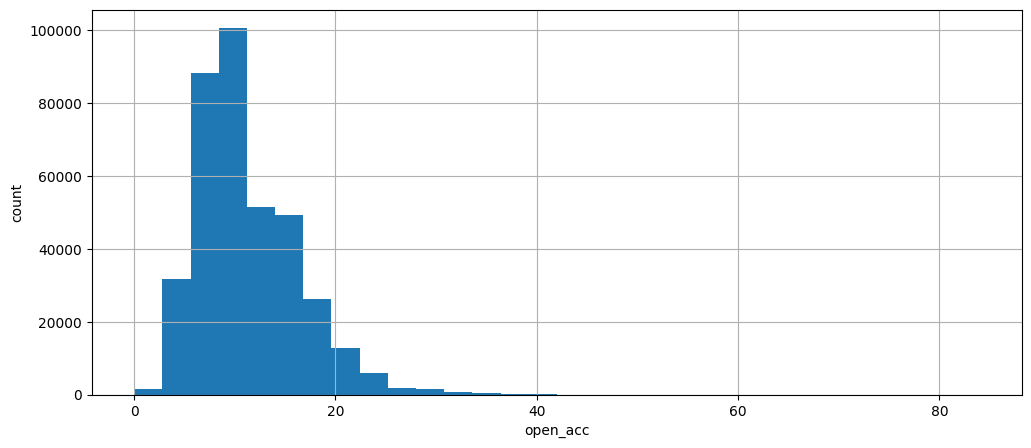

In [94]:
quick_eda(train_df, 'open_acc')

In [95]:
train_df['open_acc_bin'] = pd.qcut(train_df['open_acc'], q=10, duplicates='drop')


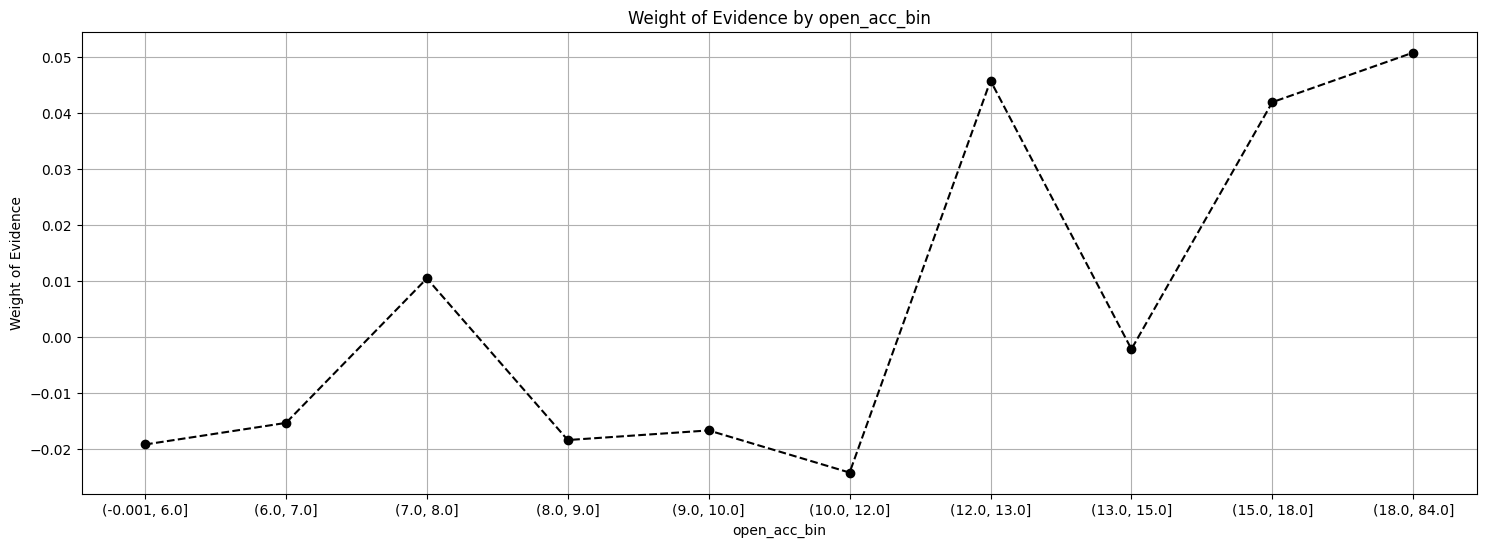

In [96]:
woe_grp.fit(train_df.drop(columns=['good_bad']), y_train, discrete_vars=['open_acc_bin'])
woe_grp.plot_woe('open_acc_bin')

In [97]:
OPEN_ACC_BINS=[0, 5, 10, 15, 25, 85]
train_df['open_acc_bin']=pd.cut(train_df['open_acc'],bins=OPEN_ACC_BINS)

  open_acc_bin   n_obs  n_bad  n_good  prop_n_good  prop_n_bad         WoE  \
0       (0, 5]   33278   3786   29492   0.08877107  0.09287694 -0.04521464   
1      (5, 10]  157358  17288  140070   0.42160575  0.42405995 -0.00580419   
2     (10, 15]  118793  13028  105765   0.31834928  0.31956879 -0.00382341   
3     (15, 25]   58688   6171   52517   0.15807525  0.15137727  0.04329601   
4     (25, 85]    4883    496    4387   0.01320617  0.01217837  0.08102286   

          IV  
0 0.00018565  
1 0.00001424  
2 0.00000466  
3 0.00029000  
4 0.00008328  


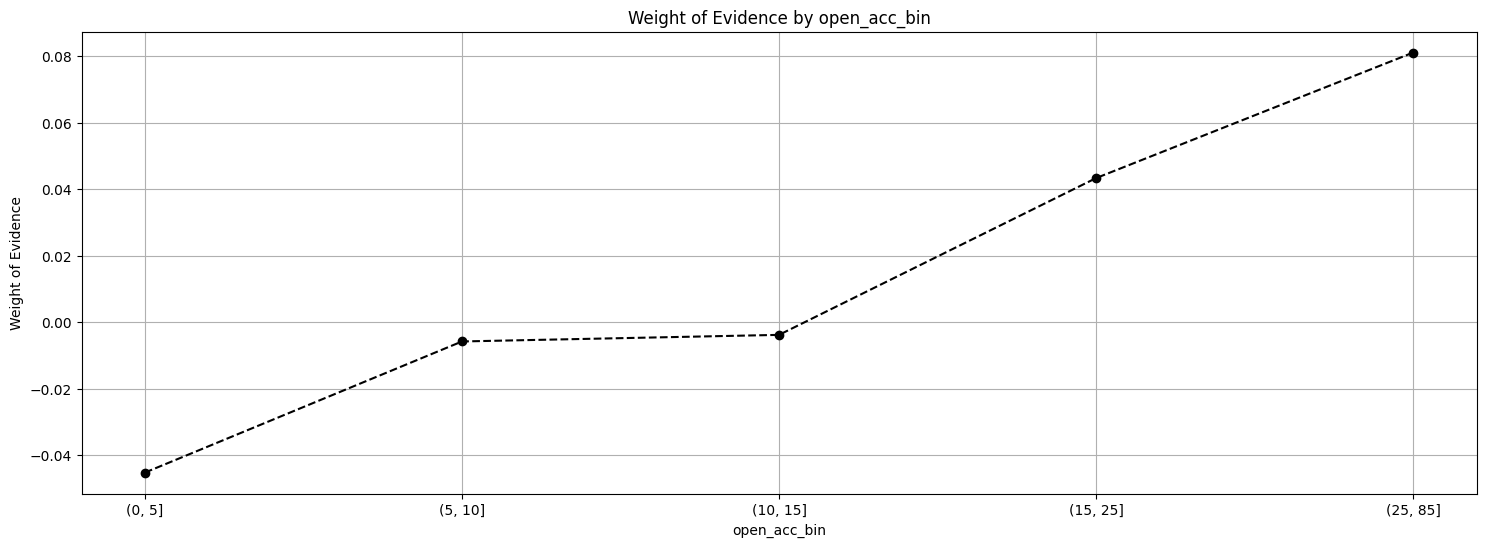

,Variable,IV
0,open_acc_bin,0.00057782


In [98]:
woe_grp.fit(train_df.drop(columns=['good_bad']), y_train, discrete_vars=['open_acc_bin'])
print(woe_grp.woe_tables['open_acc_bin'])
woe_grp.plot_woe('open_acc_bin')
woe_grp.iv_summary()

**open_acc**
- The variable represents the number of currently open credit accounts and was evaluated as a proxy for borrower credit activity and credit profile depth.
- Exploratory analysis showed a moderately right-skewed distribution, with most borrowers concentrated within low-to-moderate open account ranges.
- Initial quantile-based binning produced unstable and non-smooth WoE behavior due to narrow bins and local fluctuations across adjacent account ranges.
- To improve interpretability and statistical stability, manual binning was applied using the following thresholds:
    - 0–5 accounts
    - 5–10 accounts
    - 10–15 accounts
    - 15–25 accounts
    - 25+ accounts
- The revised grouping structure reduced local WoE volatility and produced a smoother overall risk trend across account segments.
- WoE analysis suggests that borrowers with higher numbers of open accounts demonstrated slightly lower observed default risk, potentially reflecting more established credit histories and stronger credit management behavior.
- Despite improved stability after regrouping, the variable demonstrated very weak predictive contribution:
    - IV ≈ 0.00058
- Due to limited discriminatory power and minimal incremental predictive value, the variable was excluded from the final model.
- Final decision:
    - `open_acc` was not retained for modeling.

count   373028.00000000
mean        25.05350805
std         11.60025338
min          0.00000000
25%         17.00000000
50%         23.00000000
75%         32.00000000
max        156.00000000
Name: total_acc, dtype: float64

--- Number of unique values ---
unique values:111

---value counts ---
total_acc
21.00000000    13670
22.00000000    13603
20.00000000    13529
23.00000000    13337
19.00000000    13252
18.00000000    13205
24.00000000    13133
17.00000000    13075
25.00000000    12673
16.00000000    12596
Name: count, dtype: int64

---plot ---


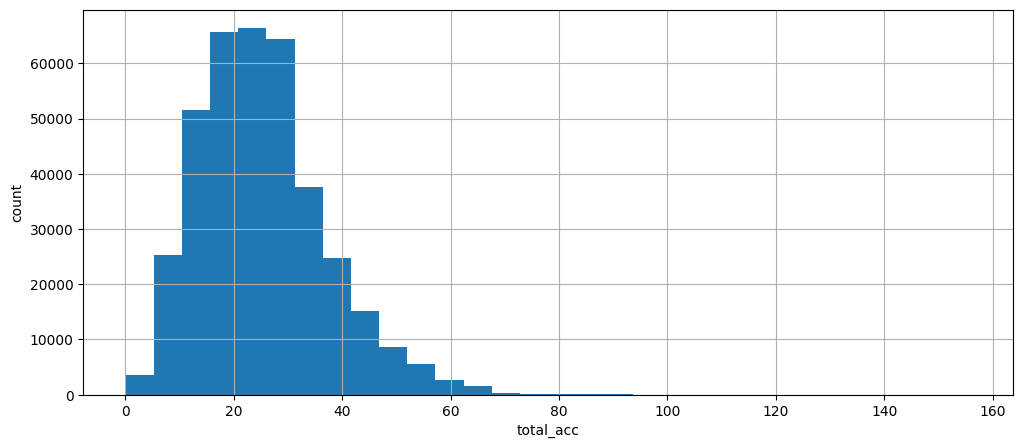

In [99]:
quick_eda(train_df, 'total_acc')

In [100]:
train_df['total_acc_bin'] = pd.qcut(train_df['total_acc'], q=10, duplicates='drop')


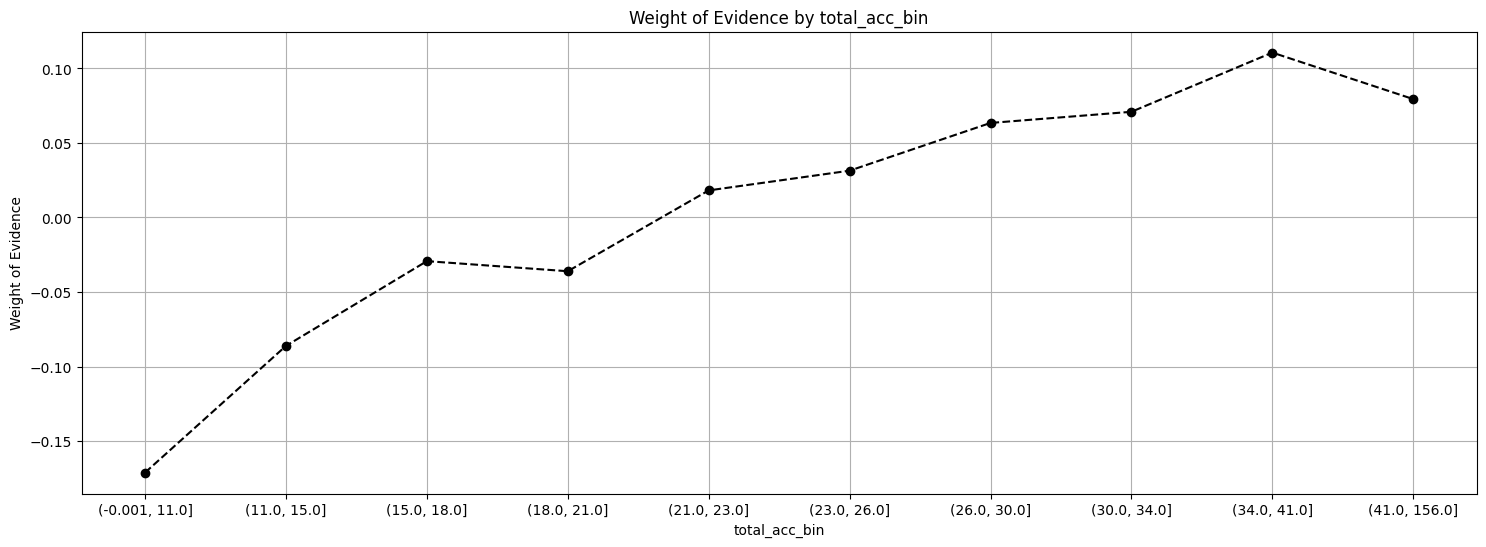

In [101]:
woe_grp.fit(train_df.drop(columns=['good_bad']), y_train, discrete_vars=['total_acc_bin'])
woe_grp.plot_woe('total_acc_bin')

In [102]:
woe_grp.iv_summary()

,Variable,IV
0,total_acc_bin,0.00701076


In [103]:
train_df=train_df.drop(columns=['total_acc_bin'])

In [104]:
train_df.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,emp_length_int,term_int,earliest_cr_line_date,credit_age_months,loan_status_clean,good_bad,home_ownership_grp,addr_state_grp,purpose_grp,mths_since_last_delinq_missing,mths_since_last_record_missing,int_rate_bin,dti_bin,credit_age_months_bin,annual_inc_bin,installment_bin,inq_last_6mths_bin,delinq_2yrs_bin,open_acc_bin
106734,106734,586040,752920,19200,19200,19200.00000000,36 months,6.03000000,584.37000000,A,A1,Morgan Stanley,5 years,MORTGAGE,85000.00000000,Verified,2013-08-01,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 07/30/13 > The loan is for...,debt_consolidation,Credit Debt,070xx,NJ,8.26000000,0.00000000,Feb-98,0.00000000,0.00000000,0.00000000,11.00000000,0.00000000,31076,52.50000000,20.00000000,w,0.00000000,0.00000000,20442.46936000,20442.47000000,19200.00000000,1242.47000000,0.00000000,0.00000000,0.00000000,Dec-14,11676.92000000,0,Jan-16,0.00000000,0.00000000,1,INDIVIDUAL,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,379491.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,59162.00000000,0.00000000,0.00000000,0.00000000,5.00000000,36,1998-02-01,188,Fully Paid,0,MORTGAGE,MEDIUM_RISK,medium_risk,0,0,"(0, 10]","(7, 12]","(160, 200]","(80000, 120000]","(450, 700]","(-1, 0]","(-1, 0]","(10, 15]"
183573,183573,2214837,2626993,24500,24500,24475.00000000,60 months,22.47000000,683.23000000,E,E5,Computer Sciences Corporation,10+ years,MORTGAGE,110000.00000000,Verified,2012-11-01,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 11/21/12 > This is a debt ...,debt_consolidation,Consolidation Loan,762xx,TX,19.17000000,1.00000000,Sep-93,3.00000000,12.00000000,0.00000000,12.00000000,0.00000000,17599,64.50000000,36.00000000,w,0.00000000,0.00000000,29877.53141000,29847.08000000,24500.00000000,5377.53000000,0.00000000,0.00000000,0.00000000,Apr-14,670.65000000,0,Jan-16,0.00000000,0.00000000,1,INDIVIDUAL,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,249672.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,27300.00000000,0.00000000,0.00000000,0.00000000,10.00000000,60,1993-09-01,233,Fully Paid,0,MORTGAGE,LOW_RISK,medium_risk,0,0,"(20, 30]","(17, 24]","(200, 260]","(80000, 120000]","(450, 700]","(1, 3]","(0, 3]","(10, 15]"
52853,52853,9394616,11226763,6400,6400,6400.00000000,36 months,8.90000000,203.23000000,A,A5,IT Specialist,9 years,MORTGAGE,110700.00000000,Not Verified,2013-12-01,Current,n,https://www.lendingclub.com/browse/loanDetail....,0,debt_consolidation,Tuition,117xx,NY,19.02000000,2.00000000,Nov-98,0.00000000,15.00000000,0.00000000,8.00000000,0.00000000,4070,50.90000000,42.00000000,w,2138.81000000,2138.81000000,5080.75000000,5080.75000000,4261.19000000,819.56000000,0.00000000,0.00000000,0.00000000,Jan-16,203.23000000,Feb-16,Jan-16,0.00000000,0.00000000,1,INDIVIDUAL,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,231381.00000000,0.00000000,

In [105]:
TOTAL_ACC_BINS_BINS=[0,10, 20, 30,45, 160]
train_df['total_acc_bin']=pd.cut(train_df['total_acc'],bins=TOTAL_ACC_BINS_BINS)

  total_acc_bin   n_obs  n_bad  n_good  prop_n_good  prop_n_bad         WoE  \
0       (0, 10]   28941   3733   25208   0.07587574  0.09157020 -0.18800886   
1      (10, 20]  117121  13491  103630   0.31192021  0.33090111 -0.05907214   
2      (20, 30]  121685  12913  108772   0.32739726  0.31672471  0.03314130   
3      (30, 45]   84102   8503   75599   0.22754896  0.20856225  0.08712786   
4     (45, 160]   21157   2132   19025   0.05726536  0.05230305  0.09064122   

          IV  
0 0.00295070  
1 0.00112124  
2 0.00035370  
3 0.00165427  
4 0.00044979  


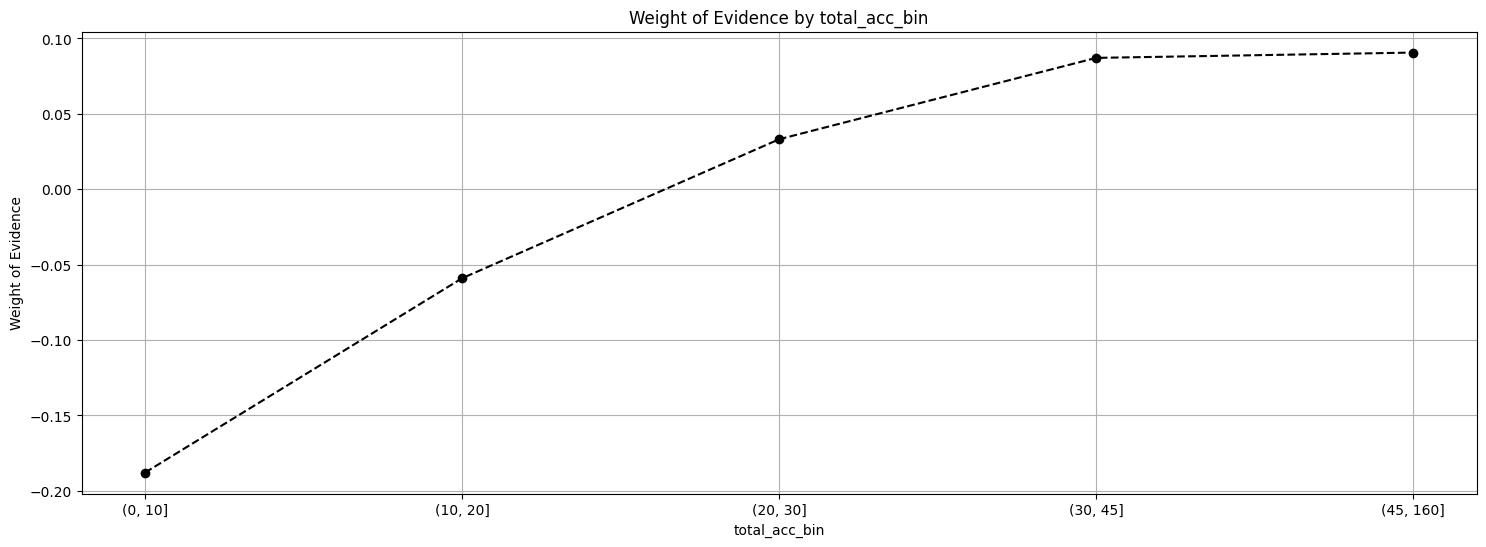

,Variable,IV
0,total_acc_bin,0.00652970


In [106]:
woe_grp.fit(train_df.drop(columns=['good_bad']), y_train, discrete_vars=['total_acc_bin'])
print(woe_grp.woe_tables['total_acc_bin'])
woe_grp.plot_woe('total_acc_bin')
woe_grp.iv_summary()

**total_acc**
- The variable represents the total number of credit accounts in the borrower’s credit history and was evaluated as a measure of overall credit experience and credit profile depth.
- Exploratory analysis showed a moderately right-skewed distribution, with most borrowers concentrated within low-to-moderate account ranges.
- Initial WoE analysis demonstrated a generally monotonic increasing relationship:
    - lower account counts → lower WoE → higher risk
    - higher account counts → higher WoE → lower risk
- To improve interpretability and reduce excessive granularity from quantile-based segmentation, manual binning was applied using the following thresholds:
    - 0–10 accounts
    - 10–20 accounts
    - 20–30 accounts
    - 30–45 accounts
    - 45+ accounts
- The revised grouping structure produced stable monotonic WoE behavior while preserving meaningful borrower credit-history segmentation.
- The variable demonstrated weak but stable predictive contribution:
    - IV ≈ 0.0065
- The observed behavior aligns with financial intuition, where borrowers with longer and more established - credit histories generally exhibited lower observed default risk.
- Final variable used:
    - `total_acc_bin`